# Figure 1A

In [10]:
import os
import tifffile
from imaris_ims_file_reader.ims import ims
import numpy as np
import napari
from cellpose import models
from cellpose.utils import stitch3D

# import utils from the parent directory
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.stitch_3d import stitch_3d 

# Load in example image to show slices
name = "ExpBSc2_TL_ITD1_20x_260513_F08"
input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data"
frame = 16
channel = 2 #crc channel
# image = ims(os.path.join(input_directory, f"{name}.ims"))[frame, channel] 
cropped = ims(os.path.join(input_directory, f"{name}_cropped.ims"))[frame, channel] 
print(cropped.shape)
# segmentation = tifffile.imread(os.path.join(input_directory, f"{name}_segmented.tif"))[frame, :]
# print(segmentation.shape)


# model = models.CellposeModel(
#         gpu=("cuda" == "cuda"), pretrained_model=r"C:\Users\6331823\Local SSD\20260511 CARE BSc\Train Low segmenter\models\low_input"
#     )
# model = models.CellposeModel(
#         gpu=("cuda" == "cuda"), pretrained_model=r"C:\Users\6331823\Local SSD\Coding projects\organoid_segmenter\models\2d_high_quality_model"
#     )


# cp = []
# for z in range(cropped.shape[0]):
#     print(f"Running cellpose on z-slice {z}...")
#     masks, _, _ = model.eval(cropped[z],
#                 diameter=None,
#                 normalize=True,
#                 flow_threshold=0.4,
#                 invert=False,
#                 resample=True,
#                 do_3D=False,
#                 progress=None,
#                 )
#     cp.append(masks)
# cp = np.stack(cp, axis=0)
# cp = stitch3D(cp)
# tifffile.imwrite(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"), cp.astype(np.uint16))

cp = tifffile.imread(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"))
print(f"Cellpose seg cell numbers: {len(np.unique(cp))}")
nuclogic = stitch_3d(cp, cropped, breaking_threshold = 0.3)
# nuclogic2 = stitch_3d(nuclogic, cropped)

# Show in napari
contrast = (np.median(cropped) * 1.2, np.percentile(cropped, 99.98))
scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)
viewer.dims.ndisplay = 3
y_half = slice(0, cropped.shape[1] // 2)
x_half = slice(0, cropped.shape[2])
print(y_half, x_half)
viewer.add_image(cropped[:, y_half, x_half], contrast_limits=contrast, scale=scale)
viewer.add_labels(cp[:, y_half, x_half], scale=scale, iso_gradient_mode="smooth", visible=False)
viewer.add_labels(nuclogic[:, y_half, x_half], scale=scale, iso_gradient_mode="smooth", visible=False)
# viewer.add_image(cropped, contrast_limits=contrast, scale=scale)
# viewer.add_labels(cp, scale=scale, iso_gradient_mode="smooth", visible=False)
# viewer.add_labels(nuclogic, scale=scale, iso_gradient_mode="smooth", visible=False)
# viewer.add_labels(nuclogic2, scale=scale, iso_gradient_mode="smooth", visible=False)

# Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.reset_view()
viewing_angle = (180, 0, 0)
viewer.camera.angles = viewing_angle

Opening readonly file: C:\Users\6331823\Local SSD\NucLogic paper figure data\ExpBSc2_TL_ITD1_20x_260513_F08_cropped.ims 

Closing file: C:\Users\6331823\Local SSD\NucLogic paper figure data\ExpBSc2_TL_ITD1_20x_260513_F08_cropped.ims 

(63, 294, 290)
Cellpose seg cell numbers: 310
Starting 3D stitching process...
Creating unique mask for properties calculation...
Unique mask created with 2095 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 311 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 58 breaks.
    Iteration 2: Made 22 breaks.
    Iteration 3: Made 16 breaks.
    Iteration 4: Made 3 breaks.
Finding touching cell pairs...
Found 347 pairs of touching cells.
Splitted 70 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 10 small cells, and removed 15 cells without suitable neighbors.
Final stitched mask has 385 cells.
slice(0, 147, None) slice(0, 290, None

Figure 2

In [1]:
# Figure 2A

import os
import tifffile
from imaris_ims_file_reader.ims import ims
import numpy as np
import napari
import scipy.ndimage

# import utils from the parent directory
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.stitch_3d import stitch_3d 
from utils.expand_mask import expand_mask_3d

# Load in example image to show slices
name = "ExpBSc2_TL_ITD1_20x_260513_F08"
input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data"
frame = 16
channel = 2 #crc channel
# image = ims(os.path.join(input_directory, f"{name}.ims"))[frame, channel] 
cropped = ims(os.path.join(input_directory, f"{name}_cropped.ims"))[frame, channel] 
print(cropped.shape)

# cp = []
# for z in range(cropped.shape[0]):
#     print(f"Running cellpose on z-slice {z}...")
#     masks, _, _ = model.eval(cropped[z],
#                 diameter=None,
#                 normalize=True,
#                 flow_threshold=0.4,
#                 invert=False,
#                 resample=True,
#                 do_3D=False,
#                 progress=None,
#                 )
#     cp.append(masks)
# cp = np.stack(cp, axis=0)
# cp = stitch3D(cp)
# tifffile.imwrite(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"), cp.astype(np.uint16))

cp = tifffile.imread(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"))
print(f"Cellpose seg cell numbers: {len(np.unique(cp))}")
nuclogic = stitch_3d(cp, cropped, breaking_threshold = 2)
# nuclogic2 = stitch_3d(nuclogic, cropped)

# Show in napari
contrast = (np.median(cropped) * 1.2, np.percentile(cropped, 99.98))
scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)
viewer.dims.ndisplay = 3
y_half = slice(0, cropped.shape[1] // 2)
x_half = slice(0, cropped.shape[2])
print(y_half, x_half)

selected_mask_cp = cp == 167  # show only the mask for cell 174
selected_mask_cp = np.where(selected_mask_cp, cp, 0)  # create a masked image where only the selected cell is visible
# cropped_masked = expand_mask_3d(selected_mask_cp, dilation_size_um = 2, voxel_size=scale)  # dilate the mask to make it more visible
# cropped_masked = np.where(cropped_masked, cropped, 0)  # create a masked image where only the selected cell is visible
selected_ids_nuclogic = [166, 336]
selected_mask_nuclogic = np.isin(nuclogic, selected_ids_nuclogic)  # create mask where the selected cells are visible
selected_mask_nuclogic = np.where(selected_mask_nuclogic, nuclogic, 0)  # create a masked image where only the selected cells are visible
# target_z = np.where(selected_mask_nuclogic)[0].min() + 5
# nuclogic_display = nuclogic.copy()
# # replace both cell IDs only in that single slice
# nuclogic_display[target_z][np.isin(nuclogic_display[target_z], [166, 336])] = 166


# viewer.add_image(cropped, contrast_limits=contrast, scale=scale)
# viewer.add_image(cropped_masked, contrast_limits=(contrast[0], contrast[1]/1.7), scale=scale, colormap="Greys")
viewer.add_labels(selected_mask_cp, scale=scale, colormap={0: "", 167: "magenta"}, iso_gradient_mode="smooth", visible=True, opacity=1)
# viewer.add_labels(nuclogic_display, scale=scale, colormap={0: "", 166: "magenta", 336: "lime"}, iso_gradient_mode="smooth", visible=True, opacity=1)
# viewer.add_labels(nuclogic, scale=scale, iso_gradient_mode="smooth", visible=False)

# # Reset view to the data bounds, then set a side-view camera angle (XZ view)
# viewer.reset_view()
# viewer.camera.center = (83.24123779650657, 96.3297331771258, 59.20690029145916)
# viewer.camera.angles = (180, 0.6526549938471702, 0.413991687612314)
# viewer.camera.zoom = 12.308777811410637
# @viewer.bind_key('c')  # press 'c' to capture camera state
# def print_camera(viewer):
#     print(f"viewer.camera.center = {viewer.camera.center}")
#     print(f"viewer.camera.angles = {viewer.camera.angles}")
#     print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

# # make scale bar visible
# viewer.scale_bar.visible = True
# viewer.scale_bar.unit = 'µm'
# #toggle grid mode on
# viewer.grid.enabled = True
# viewer.theme = 'light'

# # save screenshot
# output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
# napari.run()
# # viewer.screenshot(path=os.path.join(output_directory, "2A.png"), canvas_only=True, scale = 2)

Opening readonly file: C:\Users\6331823\Local SSD\NucLogic paper figure data\ExpBSc2_TL_ITD1_20x_260513_F08_cropped.ims 

Closing file: C:\Users\6331823\Local SSD\NucLogic paper figure data\ExpBSc2_TL_ITD1_20x_260513_F08_cropped.ims 

(63, 294, 290)
Cellpose seg cell numbers: 310
Starting 3D stitching process...
Creating unique mask for properties calculation...
Unique mask created with 2095 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 311 cells formed.
Starting iterative breaking of cells
Cell 166 break scores:
  Volume break scores: [0, 0.9032813846033362, 0.7951773315819103, 1.2251157407407407, 1.1290666666666669, 0.8769322235434006, 1.387234809242827, 0.8830795748348177, 0.8891657766702267, 0.8779217558435117, 0]
  Intensity break scores: [0, 0.8492980268904382, 0.91223470190151, 0.8789276647534391, 0.9990466362153788, 1.387835958498404, 1.022743029860302, 0.9343847063029113, 1.046150241330675, 1.

c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\standardize_color.py:91: UserWarning: Empty string detected. Returning black instead.
  warnings.warn(


<Labels layer 'selected_mask_cp' at 0x1d900553a90>

In [2]:
# print the most bottom nonzero slice of the selected mask to check if the bottom part of the cell is still visible
print("Most bottom nonzero slice of the selected mask:")
print(np.where(selected_mask_nuclogic)[0].min())

Most bottom nonzero slice of the selected mask:
28


In [ ]:
# Figure 2A_bottom
# Show in napari

scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)


# viewer.add_image(cropped, contrast_limits=contrast, scale=scale)
# viewer.add_image(cropped_masked, contrast_limits=(contrast[0], contrast[1]/1.7), scale=scale, colormap="Greys")
viewer.add_labels(selected_mask_cp, scale=scale, colormap={0: "", 167: "magenta"}, iso_gradient_mode="smooth", visible=True, opacity=1)
viewer.add_labels(nuclogic_display, scale=scale, colormap={0: "", 166: "magenta", 336: "lime"}, iso_gradient_mode="smooth", visible=True, opacity=1)


# Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.reset_view()
viewer.camera.center = (81.7789406621335, 22.667029017368154, 88.64139740486563)
viewer.camera.angles = (178.06352653830456, -84.03938801581167, 2.1125919814583987)
viewer.camera.zoom = 12.308777811410637
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
viewer.theme = 'light'

# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
# viewer.screenshot(path=os.path.join(output_directory, "2A_bottom.png"), canvas_only=True, scale = 3)

c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


In [2]:
# Figure 2b final
# Show in napari

scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)

selected_ids_nuclogic = [166, 343]
selected_mask_nuclogic = np.isin(nuclogic, selected_ids_nuclogic)  # create mask where the selected cells are visible
# selected_mask_nuclogic = np.where(selected_mask_nuclogic, nuclogic, 0)  # create a masked image where only the selected cells are visible

viewer.add_labels(nuclogic, scale=scale, iso_gradient_mode="smooth", visible=False)
nuclogic2 = stitch_3d(nuclogic, cropped, breaking_threshold = 2)
viewer.add_labels(nuclogic2, scale=scale, iso_gradient_mode="smooth", visible=False)
# viewer.add_labels(selected_mask_nuclogic, scale=scale, colormap={0: "", 166: "magenta", 343: "lime"}, iso_gradient_mode="smooth", visible=True, opacity=1)


# Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.reset_view()
viewer.camera.center = (81.7789406621335, 22.667029017368154, 88.64139740486563)
viewer.camera.angles = (178.06352653830456, -84.03938801581167, 2.1125919814583987)
viewer.camera.zoom = 12.308777811410637
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
viewer.theme = 'light'

# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
viewer.screenshot(path=os.path.join(output_directory, "2B_final.png"), canvas_only=True, scale = 3)

Starting 3D stitching process...
Creating unique mask for properties calculation...
Unique mask created with 2213 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 364 cells formed.
Starting iterative breaking of cells
Cell 166 break scores:
  Volume break scores: [0, 2.3714285714285714, 0.8465608465608466, 0.8779213238496153, 0.9096137152777779, 1.0520833333333335, 0.8469757866875796, 0.8603703703703703, 0]
  Intensity break scores: [0, 0.9282447968593451, 1.0870938958260137, 1.217307202571666, 0.996838532179134, 0.8590281509355322, 0.9518647819844411, 1.1132058805582201, 0]
  Line break scores (up): [0.         0.         1.15613345 3.80633368 2.32554158 0.21497982
 0.41075812 0.19655939 0.0941902 ]
  Line distances (up): [0.57806672 1.15613345 0.57806672 3.80633368 4.70905905 5.3968046
 6.49530828 7.79037133 9.17962459]
  Line break scores (down): [0.         1.16928662 1.79121567 0.94175093 0.13594289 

array([[[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       ...,

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255

In [15]:
# Figure synthetic data
# Code to create synthetic data for testing the stitching algorithm
from skimage.draw import ellipsoid
import napari
import os
from scipy.ndimage import zoom, gaussian_filter
import numpy as np
from scipy.ndimage import binary_dilation


def make_cell(radius_Z, radius_Y, radius_X, intensity=255):
    """Create a binary ellipsoidal cell"""
    cell = ellipsoid(radius_Z, radius_Y, radius_X)
    cell = cell.astype(np.uint16) * intensity
    return cell


def paste_cell(volume, mask, cell, position, label):
    cz, cy, cx = position.astype(int)
    dz, dy, dx = cell.shape
    hz, hy, hx = dz // 2, dy // 2, dx // 2

    z0, z1 = max(0, cz - hz), min(volume.shape[0], cz + hz + 1)
    y0, y1 = max(0, cy - hy), min(volume.shape[1], cy + hy + 1)
    x0, x1 = max(0, cx - hx), min(volume.shape[2], cx + hx + 1)

    cell_z0 = hz - (cz - z0)
    cell_y0 = hy - (cy - y0)
    cell_x0 = hx - (cx - x0)

    subcell = cell[
        cell_z0 : cell_z0 + (z1 - z0),
        cell_y0 : cell_y0 + (y1 - y0),
        cell_x0 : cell_x0 + (x1 - x0),
    ]

    if subcell.size == 0:
        return False

    volume[z0:z1, y0:y1, x0:x1] = np.maximum(volume[z0:z1, y0:y1, x0:x1], subcell)
    mask[z0:z1, y0:y1, x0:x1][subcell > 0] = label
    return True

from scipy.ndimage import affine_transform


def _rotation_matrix(from_vec, to_vec):
    a = from_vec / (np.linalg.norm(from_vec) + 1e-8)
    b = to_vec / (np.linalg.norm(to_vec) + 1e-8)
    v = np.cross(a, b)
    c = np.dot(a, b)
    if np.isclose(c, 1.0):
        return np.eye(3)
    if np.isclose(c, -1.0):
        # 180° flip around any perpendicular axis
        perp = np.array([1.0, 0.0, 0.0])
        if np.allclose(a, perp):
            perp = np.array([0.0, 1.0, 0.0])
        v = perp - a * np.dot(perp, a)
        v /= np.linalg.norm(v)
        vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
        return np.eye(3) + 2 * vx @ vx
    vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
    return np.eye(3) + vx + vx @ vx * ((1 - c) / (np.linalg.norm(v) ** 2 + 1e-8))


def orient_cell(cell, direction_vec):
    base = np.array([1.0, 0.0, 0.0])  # +z axis in (z, y, x) ordering
    pad = int(max(cell.shape) * 0.75)
    padded = np.pad(
        cell,
        ((pad, pad), (pad, pad), (pad, pad)),
        mode="constant",
        constant_values=0,
    )
    R = _rotation_matrix(base, direction_vec)
    center = (np.array(padded.shape) - 1) / 2
    matrix = R.T
    offset = center - matrix @ center
    rotated = affine_transform(
        padded,
        matrix=matrix,
        offset=offset,
        order=1,
        mode="constant",
        cval=0,
    )
    return rotated.astype(cell.dtype)


def can_place(mask, cell, position, min_gap=4):
    dilated_cell = binary_dilation(cell > 0, iterations=min_gap)
    cz, cy, cx = position.astype(int)
    dz, dy, dx = dilated_cell.shape
    hz, hy, hx = dz // 2, dy // 2, dx // 2

    z0, z1 = max(0, cz - hz), min(mask.shape[0], cz + hz + 1)
    y0, y1 = max(0, cy - hy), min(mask.shape[1], cy + hy + 1)
    x0, x1 = max(0, cx - hx), min(mask.shape[2], cx + hx + 1)

    if z0 >= z1 or y0 >= y1 or x0 >= x1:
        return False

    cell_z0 = hz - (cz - z0)
    cell_y0 = hy - (cy - y0)
    cell_x0 = hx - (cx - x0)

    subcell = dilated_cell[
        cell_z0 : cell_z0 + (z1 - z0),
        cell_y0 : cell_y0 + (y1 - y0),
        cell_x0 : cell_x0 + (x1 - x0),
    ]

    return np.all(mask[z0:z1, y0:y1, x0:x1][subcell > 0] == 0)

def generate_synthetic_organoid(number_of_cells = 250, max_attempts = 30, radius_X = 12, radius_Y = 12, radius_Z = 5, randomness = 0.2, vol_shape = (300,300,300), organoid_size = 250):
    volume = np.zeros(vol_shape, dtype=np.uint16)
    mask = np.zeros_like(volume)

    center = np.array(vol_shape) // 2

    for cell_idx in range(number_of_cells):
        # create a binomial distrubution around the radii with the arms reaching the randomness value
        rand_radius_X = int(radius_X + np.random.uniform(-randomness, randomness) * radius_X)
        rand_radius_Y = int(radius_Y + np.random.uniform(-randomness, randomness) * radius_Y)
        rand_radius_Z = int(radius_Z + np.random.uniform(-randomness, randomness) * radius_Z)
        cell = make_cell(rand_radius_Z, rand_radius_Y, rand_radius_X, intensity=255)

        placed = False
        for attempt in range(max_attempts):
            # get a random position at distance of organoid_size/2 from center
            u = np.random.uniform(-1, 1)  # cos(theta)
            phi = np.random.uniform(0, 2 * np.pi)
            theta = np.arccos(u)
            r = organoid_size / 2 # controls how far from center the cells are placed
            pos_z = int(center[0] + r * u)
            sin_theta = np.sqrt(1 - u * u)
            pos_y = int(center[1] + r * sin_theta * np.cos(phi))
            pos_x = int(center[2] + r * sin_theta * np.sin(phi))
            position = np.array([pos_z, pos_y, pos_x])

            # place the cell in the volume at the random position
            direction = center - position  # point toward organoid center
            oriented_cell = orient_cell(cell, direction)

            if not can_place(mask, oriented_cell, position):
                continue

            paste_success = paste_cell(volume, mask, oriented_cell, position, label=cell_idx + 1)
            if paste_success:
                placed = True
                print(
                    f"Cell {cell_idx+1}: position=({pos_z}, {pos_y}, {pos_x}), radii=({rand_radius_Z}, {rand_radius_Y}, {rand_radius_X})"
                )
                break

        if not placed:
            print(f"Cell {cell_idx}: skipped after {max_attempts} attempts")

    return volume, mask

seed = 1
np.random.seed(seed)
rng = np.random.default_rng(seed)

def generate_synthetic_data(number_of_cells = 250, max_attempts = 30, radius_X = 12, radius_Y = 12, radius_Z = 5, randomness = 0.2, vol_shape = (300,300,300), organoid_size = 250):

    synthetic_organoid, synthetic_mask = generate_synthetic_organoid(number_of_cells = number_of_cells, max_attempts = max_attempts, radius_X = radius_X, radius_Y = radius_Y, radius_Z = radius_Z, randomness = randomness, vol_shape = vol_shape, organoid_size = organoid_size)
    rescale = ((synthetic_organoid.shape[0] / (2.5 / 0.64) / synthetic_organoid.shape[0]), 1.0, 1.0)
    synthetic_organoid = zoom(synthetic_organoid, zoom=rescale, order=1)
    mask = zoom(synthetic_mask, zoom=rescale, order=0)
    output_directory = r"C:\Users\6331823\Local SSD\Fake_data"

    unique_labels = np.unique(mask)
    unique_labels = unique_labels[unique_labels > 0]

    brightness_volume = np.zeros_like(synthetic_organoid, dtype=np.float32)

    for lbl in unique_labels:
        cell_voxels = mask == lbl
        cell_mean = np.clip(rng.normal(150, 30), 50, 300)
        cell_noise = rng.normal(loc=cell_mean, scale=5, size=cell_voxels.sum())
        lo = max(150, cell_mean - 10)
        hi = min(250, cell_mean + 10)
        brightness_volume[cell_voxels] = np.clip(cell_noise, lo, hi)

    brightness_volume = brightness_volume.astype(np.uint16)


    # # create noise and PSF
    # gaussian_volume = gaussian_filter(
    #     brightness_volume.astype(np.float32), sigma=(1.6, 0.6, 0.6)
    # )
    # treat the per-cell brightness as photon counts (so Poisson SNR is meaningful)
    signal_photons = brightness_volume.astype(np.float32)

    # --- PSF (optics) : anisotropic, effective = diffraction floor + tissue scatter ---
    # em, NA, n = 0.680, 1.0, 1.33                 # 638 ex -> ~680 em far-red, water immersion
    # vox = np.array([2.5, 0.64, 0.64])            # (z, y, x) um after the zoom
    # fwhm = np.array([1.4 * n * em / NA**2, 0.51 * em / NA, 0.51 * em / NA])
    # sigma_diffraction = fwhm / 2.355 / vox       # ~sub-voxel at this sampling
    # sigma_eff = np.maximum(sigma_diffraction, [2, 0.7, 0.7])   # your values, as scatter floor
    blurred = np.empty_like(signal_photons)
    nz = signal_photons.shape[0]
    for z in range(nz):
        depth_frac = (z / nz)**0.5                      # 0 = bottom (near objective), 1 = deep
        sz = 1 + 1.6 * depth_frac              # axial blur grows with depth
        sxy = 0.5 + 0.5 * depth_frac             # lateral blur grows with depth
        # blur a small Z-window around slice z so axial smear is captured
        z0, z1 = max(0, z-4), min(nz, z+5)
        blurred[z] = gaussian_filter(signal_photons[z0:z1], sigma=(sz, sxy, sxy))[z-z0]

    # --- depth-dependent signal loss (absorption/scattering deeper in the organoid) ---
    depth = np.linspace(0.0, 1.0, blurred.shape[0], dtype=np.float32)   # 0 = top, 1 = deepest
    top, bottom = 1, 0.01
    sqrt_part = top - (top - bottom) * np.sqrt(depth)
    d0, k, deep_drop, boost = 0.4, 20.0, 0.5, 0.15 
    sigmoid = 1.0 / (1.0 + np.exp(-k * (depth - d0)))           # ~0 shallow -> ~1 deep
    factor  = (1.0 + boost) - (boost + deep_drop) * sigmoid     # (1+boost) shallow -> (1-deep_drop) deep
    z_profile = (sqrt_part * factor)[:, None, None]
    photons = blurred * z_profile + 3.0          # + small autofluorescence/stray-light background

    # --- NOISE at the detector (this is the part the Gaussian was missing) ---
    detected = rng.poisson(photons).astype(np.float32)   # shot noise (signal-dependent)
    detected += rng.normal(0, 1.5, detected.shape)       # sCMOS read noise ~1-2 e-
    realistic_volume = np.clip(detected + 100.0, 0, 65535).astype(np.uint16)  # +camera offset

    return realistic_volume, mask

# print(realistic_volume.sum())
# output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
# tifffile.imwrite(os.path.join(output_directory, "synthetic_organoid.tif"), realistic_volume)
# tifffile.imwrite(os.path.join(output_directory, "synthetic_organoid_gt.tif"), mask.astype(np.uint16))

(61, 378, 490)


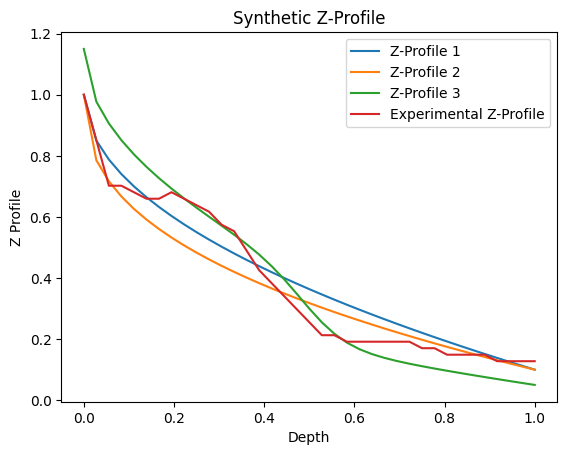

In [170]:
import matplotlib.pyplot as plt
from imaris_ims_file_reader.ims import ims
import tifffile

name = "E-133_S-16_O-1.tif"
input_directory = r"D:\Data Hussein raw\E-133_S-16_O-1"
frame = 16
channel = 2 #crc channel
# image = ims(os.path.join(input_directory, f"{name}.ims"))[frame, channel] 
cropped = tifffile.imread(os.path.join(input_directory, f"{name}"))[14,:,0]
print(cropped.shape)
intensities = []
for z in range(cropped.shape[0]):
    intensities.append(np.percentile(cropped[z], 99))
# remove all values before max of intensities
intensities = intensities[np.argmax(intensities):]

depth = np.linspace(0.0, 1.0, len(intensities), dtype=np.float32)   # 0 = top, 1 = deepest
top, bottom = 1, 0.1
z_profile1 = (top - (top - bottom) * depth**0.5)[:, None, None]
z_profile2 = (top - (top - bottom) * depth**0.4)[:, None, None]

# 1) gentle sqrt falloff (your current curve)
sqrt_part = top - (top - bottom) * np.sqrt(depth)

# 2) sigmoid: slight lift before the knee, bigger drop after
d0, k, deep_drop, boost = 0.5, 20.0, 0.5, 0.15   # +boost = how much higher before the knee
sigmoid = 1.0 / (1.0 + np.exp(-k * (depth - d0)))           # ~0 shallow -> ~1 deep
factor  = (1.0 + boost) - (boost + deep_drop) * sigmoid     # (1+boost) shallow -> (1-deep_drop) deep
z_profile3 = (sqrt_part * factor)[:, None, None]

plt.plot(depth, z_profile1[:, 0, 0], label="Z-Profile 1")
plt.plot(depth, z_profile2[:, 0, 0], label="Z-Profile 2")
plt.plot(depth, z_profile3[:, 0, 0], label="Z-Profile 3")
plt.plot(depth, np.array(intensities) / np.max(intensities), label="Experimental Z-Profile")
plt.xlabel("Depth")
plt.ylabel("Z Profile")
plt.title("Synthetic Z-Profile")
plt.legend()
plt.show()

Actual size: (25.0, 9.6, 3.2), Elongation: 1.60, Break Score: 0.78


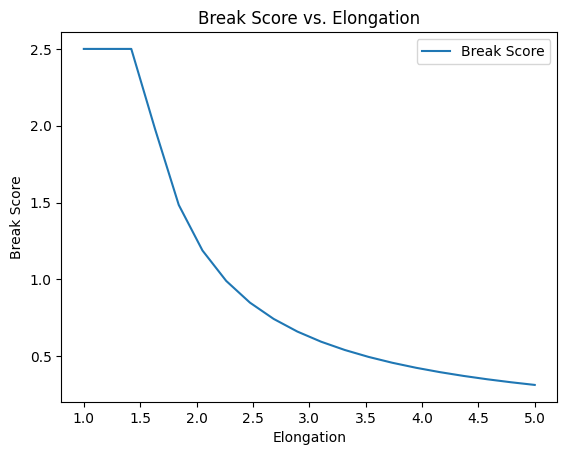

In [106]:
import matplotlib.pyplot as plt


z,y,x = 10, 15, 5
scale = (2.5, 0.64, 0.64)
actual_size = (z*scale[0], y*scale[1], x*scale[2])
sorted_size = sorted(actual_size, reverse=True)
elongation = sorted_size[0] / sorted_size[1] -1
break_score = 2.5 / (elongation *2)
print(f"Actual size: {actual_size}, Elongation: {elongation:.2f}, Break Score: {break_score:.2f}")

elongation = np.linspace(1, 5, 20, dtype=np.float32)   # 0 = top, 1 = deepest
altered_elongation = [number - 1 for number in elongation]
altered_elongation = [number if number > 0.5 else 0.5 for number in altered_elongation]
break_scores = [2.5 / (number * 2) for number in altered_elongation]

plt.plot(elongation, break_scores, label='Break Score')
plt.xlabel('Elongation')
plt.ylabel('Break Score')
plt.title('Break Score vs. Elongation')
plt.legend()
plt.show()


In [2]:
import numpy as np
from skimage.measure import regionprops

def centroid_accuracy(gt, pred_mask):
    gt = np.asarray(gt)
    pred_mask = np.asarray(pred_mask)
    if gt.shape != pred_mask.shape:
        raise ValueError("Masks must share shape")

    gt_props = regionprops(gt)
    hit_pred_labels = set()
    predicted_labels = np.array([])
    tp = fn = merged_cells = 0

    fn_list = []
    for prop in gt_props:
        centroid = np.rint(prop.centroid).astype(int)
        centroid = tuple(np.clip(centroid, 0, np.array(gt.shape) - 1))
        pred_label = pred_mask[centroid]
        predicted_labels = np.append(predicted_labels, pred_label)
        if pred_label > 0:
            if pred_label in hit_pred_labels:
                # This predicted label has already been matched to a ground truth cell
                fn += 1
                merged_cells += 1
            else:
                tp += 1
                hit_pred_labels.add(int(pred_label))
        else:
            fn += 1
            fn_list.append(int(prop.label))


    pred_labels = set(np.unique(pred_mask))
    pred_labels.discard(0)
    fp = len(pred_labels - hit_pred_labels)
    fp_list = list(pred_labels - hit_pred_labels)

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if precision + recall else 0.0

    gt_binary = gt > 0
    pred_binary = pred_mask > 0
    intersection = np.count_nonzero(gt_binary & pred_binary)
    dice = (
        (2 * intersection) / (gt_binary.sum() + pred_binary.sum())
        if (gt_binary.sum() + pred_binary.sum())
        else 0.0
    )

    return {
        "true_positives": tp,
        "false_negatives": fn,
        "false_positives": fp,
        "merged_cells": merged_cells,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "voxel_dice": dice,
        "tp_list": list(hit_pred_labels),
        "fp_list": fp_list,
        "fn_list": fn_list,
    }

# print(centroid_accuracy(gt, pred_mask))
# print(f"actual amount of cells: {len(np.unique(gt)) - 1}, predicted amount of cells: {len(np.unique(pred_mask)) - 1}")

In [136]:
from pathlib import Path
import os
import sys
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
from utils.stitch_3d import stitch_3d
import importlib
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.load_model import load_model
from utils.stitch_3d import stitch_3d
from cellpose import models
from time import time
import tifffile
import numpy as np
import pandas as pd


output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
model = load_model(r"C:\Users\6331823\Local SSD\Coding projects\organoid_segmenter\models\2d_low_quality_model")

results = []
for i in range(1):
    realistic_volume, gt = generate_synthetic_data(number_of_cells = 300, max_attempts = 150, radius_X = 12, radius_Y = 12, radius_Z = 5, randomness = 0.2, vol_shape = (420,420,420), organoid_size = 380)
    print(f"generated {len(np.unique(gt)) - 1} cells in the synthetic organoid")
    tifffile.imwrite(os.path.join(output_directory, f"synthetic_organoid.tif"), realistic_volume)
    tifffile.imwrite(os.path.join(output_directory, f"synthetic_organoid_gt.tif"), gt.astype(np.uint16))
    gt = tifffile.imread(os.path.join(output_directory, f"synthetic_organoid_gt.tif"))
    realistic_volume = tifffile.imread(os.path.join(output_directory, "synthetic_organoid.tif"))

    time_start = time()
    segmented_2d = segment(realistic_volume, model)
    time_2d_seg_start = time() 
    nuclogic_cellpose_time = time_2d_seg_start - time_start
    tifffile.imwrite(os.path.join(output_directory, "synthetic_segmented_2d.tif"), segmented_2d.astype(np.uint16))
    segmented_2d = tifffile.imread(os.path.join(output_directory, "synthetic_segmented_2d.tif"))
    nuclogic = stitch_3d(segmented_2d, realistic_volume, breaking_threshold = 6, scale=(2.5, 0.64, 0.64))
    time_nuclogic_stitch_end = time()
    nuclogic_stitch_time = time_nuclogic_stitch_end - time_2d_seg_start

    tifffile.imwrite(os.path.join(output_directory, "synthetic_segmented_nuclogic.tif"), nuclogic.astype(np.uint16))
    
    cp4,_,_ = model.eval(
                    realistic_volume,
                    diameter=None,
                    normalize=True,
                    flow3D_smooth=0.0,
                    invert=False,
                    resample=True,
                    do_3D=True,
                    z_axis=0
                )
    tifffile.imwrite(os.path.join(output_directory, "synthetic_segmented_cp4.tif"), cp4.astype(np.uint16))
    time2 = time()
    cp4 = tifffile.imread(os.path.join(output_directory, "synthetic_segmented_cp4.tif"))
    np.set_printoptions(suppress=True, precision=4)
    print(f"Real mask {len(np.unique(gt))-1},NucLogic {len(np.unique(nuclogic))-1}, Cellpose 4 {len(np.unique(cp4))-1}")
    nuclogic_time = time_nuclogic_stitch_end - time_start
    cp4_time = time2 - time_nuclogic_stitch_end
    print(f"NucLogic time: {nuclogic_time:.2f}s, Cellpose 4 time: {cp4_time:.2f}s")
    nuclogic_results = centroid_accuracy(gt, nuclogic)
    cp4_results = centroid_accuracy(gt, cp4)
    print(f"NucLogic centroid accuracy: {nuclogic_results['f1']:.4f}")
    print(f"Cellpose 4 centroid accuracy: {cp4_results['f1']:.4f}")

    print(f"Nuclogic f1 {nuclogic_results['f1']:.4f}, Cellpose 4 f1 {cp4_results['f1']:.4f}")

    results_df = pd.DataFrame(
    {
        "method": ["nuclogic", "cellpose4"],
        "f1": [nuclogic_results["f1"], cp4_results["f1"]],
        "precision": [nuclogic_results["precision"], cp4_results["precision"]],
        "recall": [nuclogic_results["recall"], cp4_results["recall"]],
        "actual_cells": [len(np.unique(gt)) - 1, len(np.unique(gt)) - 1],
        "predicted_cells": [len(np.unique(nuclogic)) - 1, len(np.unique(cp4)) - 1],
        "true_positives": [nuclogic_results["true_positives"], cp4_results["true_positives"]],
        "false_positives": [nuclogic_results["false_positives"], cp4_results["false_positives"]],
        "false_negatives": [nuclogic_results["false_negatives"], cp4_results["false_negatives"]],
        "merged_cells": [nuclogic_results["merged_cells"], cp4_results["merged_cells"]],
        "total_time": [nuclogic_time, cp4_time],
        "nuclogic_2d_time": [nuclogic_cellpose_time, 0],
        "stitching_time": [nuclogic_stitch_time, 0],
    }
    )
    name = f"synthetic_organoid_{i}"
    results_df.insert(0, "sample", name) 
    results.append(results_df)
results_df = pd.concat(results, ignore_index=True)

# results_df.to_csv(os.path.join(output_directory, "synthetic_results.tsv"), sep="\t", index=False)


Using CUDA for processing.
loaded custom model: 2d_low_quality_model
Cell 1: position=(269, 98, 68), radii=(4, 14, 12)
Cell 2: position=(24, 251, 206), radii=(4, 10, 10)
Cell 3: position=(320, 78, 291), radii=(5, 10, 11)
Cell 4: position=(127, 164, 45), radii=(4, 11, 11)
Cell 5: position=(196, 66, 334), radii=(4, 10, 10)
Cell 6: position=(132, 355, 304), radii=(5, 13, 11)
Cell 7: position=(64, 332, 214), radii=(5, 14, 9)
Cell 8: position=(356, 174, 325), radii=(5, 12, 10)
Cell 9: position=(289, 382, 216), radii=(4, 11, 12)
Cell 10: position=(39, 204, 125), radii=(4, 11, 9)
Cell 11: position=(378, 267, 144), radii=(4, 11, 13)
Cell 12: position=(366, 105, 182), radii=(4, 12, 12)
Cell 13: position=(282, 160, 41), radii=(4, 13, 12)
Cell 14: position=(248, 379, 133), radii=(5, 11, 14)
Cell 15: position=(320, 100, 101), radii=(4, 11, 11)
Cell 16: position=(224, 374, 304), radii=(5, 13, 14)
Cell 17: position=(221, 21, 188), radii=(5, 10, 9)
Cell 18: position=(288, 52, 137), radii=(4, 10, 10)


T-test for f1: t-statistic = 10.6238, p-value = 0.0000
T-test for precision: t-statistic = 4.9290, p-value = 0.0002
Removing y-tick labels for axis 1
T-test for recall: t-statistic = 13.4616, p-value = 0.0000
Removing y-tick labels for axis 2


C:\Users\6331823\AppData\Local\Temp\ipykernel_18360\1469838796.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=45, ha="right", rotation_mode="anchor")
C:\Users\6331823\AppData\Local\Temp\ipykernel_18360\1469838796.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=45, ha="right", rotation_mode="anchor")
C:\Users\6331823\AppData\Local\Temp\ipykernel_18360\1469838796.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=45, ha="right", rotation_mode="anchor")


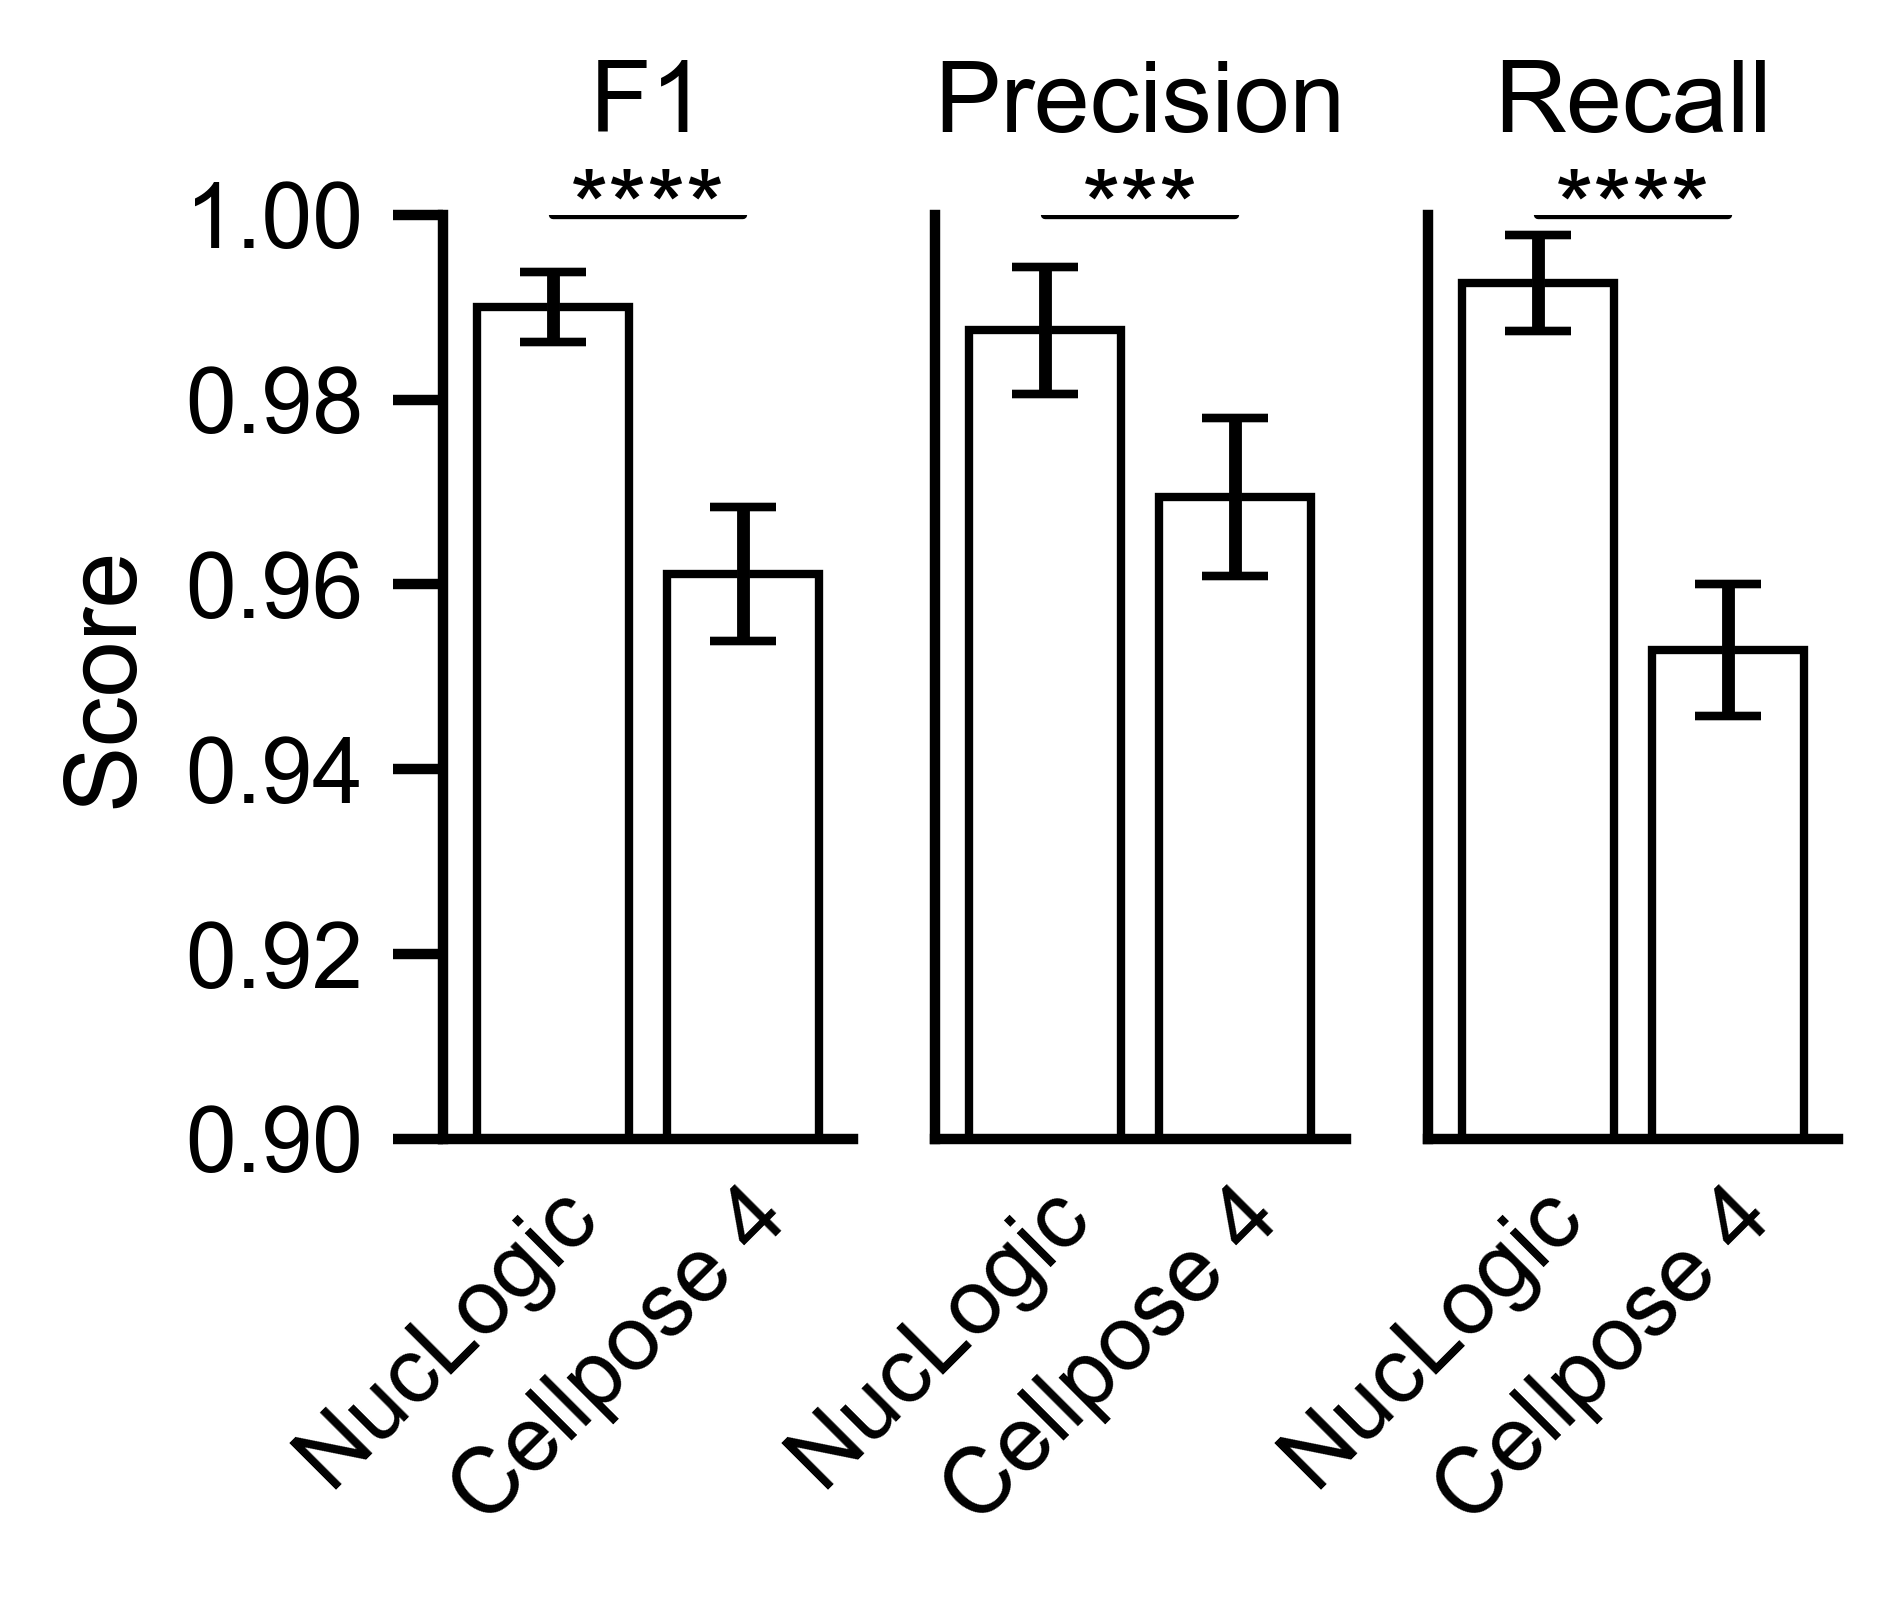

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import ttest_ind

input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results = pd.read_csv(os.path.join(input_directory, "synthetic_results.tsv"), sep="\t")
methods = ["NucLogic", "Cellpose 4"]
results["method"] = results["method"].replace({"nuclogic": "NucLogic", "cellpose4": "Cellpose 4"})
score_metrics = ["f1", "precision", "recall"]

# mean + sd per method (sd needs >1 sample per method; otherwise NaN -> no error bar)
cols = score_metrics             
agg = results.groupby("method")[cols].agg(["mean", "std"])

x = np.arange(len(methods))          # one group center per method
color = "black"

fig, axes = plt.subplots(figsize=(3, 2), ncols=3, dpi=600)

# --- 3 score bars on the LEFT axis ---
for i, metric in enumerate(score_metrics):
    means = [agg.loc[m, (metric, "mean")] for m in methods]
    sds   = [agg.loc[m, (metric, "std")]  for m in methods]

    # perform t test to check if the difference between the two methods is significant

    nuclogic_values = results[results["method"] == "NucLogic"][metric]
    cellpose_values = results[results["method"] == "Cellpose 4"][metric]
    t_stat, p_value = ttest_ind(nuclogic_values, cellpose_values, equal_var=False)
    print(f"T-test for {metric}: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")

    axes[i].bar(methods, means, yerr=sds, capsize=4, linewidth=1,
           label=metric.capitalize(), color="white", edgecolor=color)
    
    # add significance stars if p-value < 0.0001
    if p_value < 0.0001:
        text = '****'
    elif p_value < 0.001:
        text = '***'
    max_height = 1
    axes[i].plot([0, 1], [max_height, max_height], color='black', linewidth=1)
    axes[i].text(0.5, max_height - 0.005, text, ha='center', va='bottom', fontsize=12)
        
    
    axes[i].set_ylim(0.9, 1.0)
    axes[i].set_ylabel("")
    axes[i].set_title(metric.capitalize(), pad=10)
    axes[i].errorbar(x=methods, y=means, yerr=sds, fmt='none', color="black", capsize=4)
    axes[i].margins(x=0.1)

    if i != 0:
        print(f"Removing y-tick labels for axis {i}")
        axes[i].set_yticklabels("")
    else:
        axes[i].set_ylabel("Score")
        axes[i].tick_params(left=True, bottom=False) 


# --- cosmetics ---
for ax in axes:
    # move xtick slightly to right side
    ax.set_xticklabels(methods, rotation=45, ha="right", rotation_mode="anchor")
    ax.tick_params(axis="x", pad=-2)   # smaller/negative = labels move up
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    

figure_folder = os.path.join(r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures")
plt.savefig(os.path.join(figure_folder, "synthetic_results_scores.eps"), dpi=600, bbox_inches="tight")
plt.show()

C:\Users\6331823\AppData\Local\Temp\ipykernel_29420\1028593246.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=45, ha="right", rotation_mode="anchor")


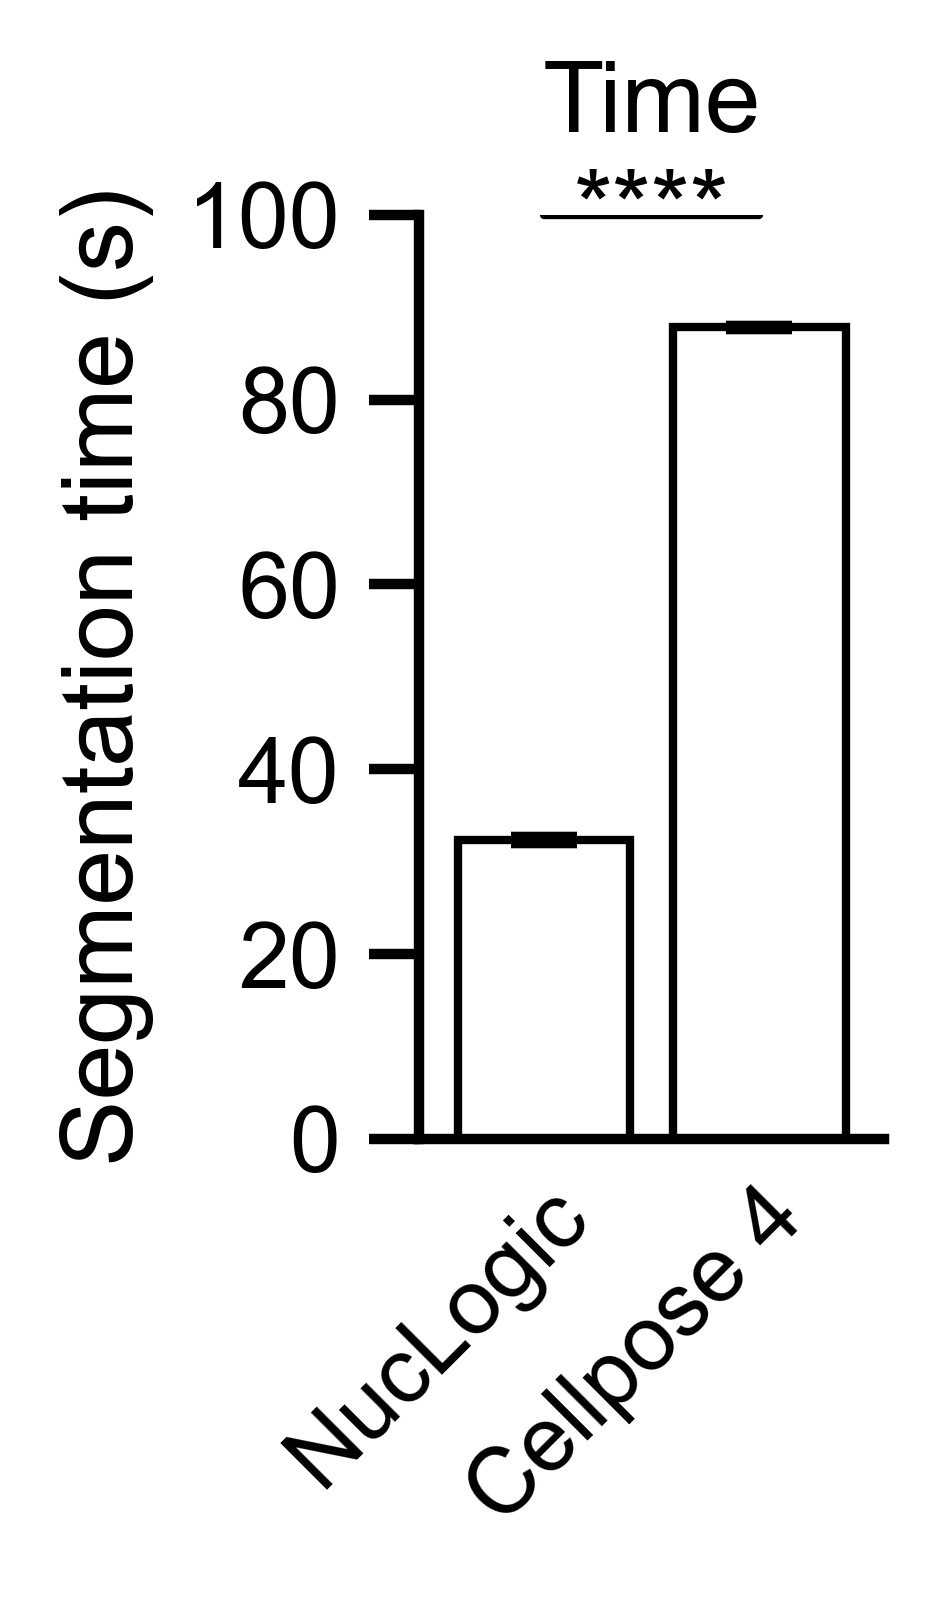

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator
input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results = pd.read_csv(os.path.join(input_directory, "synthetic_results.tsv"), sep="\t")
methods = ["NucLogic", "Cellpose 4"]
results["method"] = results["method"].replace({"nuclogic": "NucLogic", "cellpose4": "Cellpose 4"})
time_metric = "total_time"
sns.set_theme(context="notebook", style="white", rc={
    "text.color":       "black",   # generic text (annotations, legend)
    "axes.labelcolor":  "black",   # x/y axis labels
    "axes.titlecolor":  "black",   # titles
    "xtick.color":      "black",   # x tick MARKS + numbers
    "ytick.color":      "black",   # y tick MARKS + numbers
    "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
})
# mean + sd per method (sd needs >1 sample per method; otherwise NaN -> no error bar)  
cols = [time_metric]                     
agg = results.groupby("method")[cols].agg(["mean", "std"])

x = np.arange(len(methods))          # one group center per method
color =  "black"

fig, ax = plt.subplots(figsize=(1, 2), dpi=600)

# --- time bar on the RIGHT axis ---
means = [agg.loc[m, (time_metric, "mean")] for m in methods]
sds   = [agg.loc[m, (time_metric, "std")]  for m in methods]
ax.bar(x=methods, height=means, yerr=sds, capsize=4, linewidth=1,
        label="Time", color="white", edgecolor=color) # offset a little bit to the right so it doesn't overlap with the score bars
ax.errorbar(x=methods, y=means, yerr=sds, fmt='none', color="black", capsize=4)
ax.set_ylim(0, 100); ax.set_ylabel("Segmentation time (s)")
ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
ax.set_xticklabels(methods, rotation=45, ha="right", rotation_mode="anchor")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("Time", pad=10)
ax.tick_params(left=True, bottom=False) 
ax.tick_params(axis="x", pad=-2)   # smaller/negative = labels move up
ax.margins(x=0.1)

nuclogic_values = results[results["method"] == "NucLogic"][time_metric]
cellpose_values = results[results["method"] == "Cellpose 4"][time_metric]
t_stat, p_value = ttest_ind(nuclogic_values, cellpose_values, equal_var=False)
# add significance stars if p-value < 0.0001
if p_value < 0.0001:
        text = '****'
elif p_value < 0.001:
        text = '***'
max_height = 100
ax.plot([0, 1], [max_height, max_height], color='black', linewidth=1)
ax.text(0.5, max_height - 5, text, ha='center', va='bottom', fontsize=12)

figure_folder = os.path.join(r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures")
plt.savefig(os.path.join(figure_folder, "synthetic_results_time.eps"), dpi=600, bbox_inches="tight")
plt.show()

Figure 2D

In [168]:
import napari

if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
from utils.stitch_3d import stitch_3d
import importlib
importlib.reload(sys.modules["utils.stitch_3d"])

from napari.utils.colormaps import colormap_utils as cu
colormap = cu.label_colormap(num_colors=1024)
input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"


realistic_volume = tifffile.imread(os.path.join(input_directory, "synthetic_organoid.tif"))
gt = tifffile.imread(os.path.join(input_directory, "synthetic_organoid_gt.tif"))
segmented_2d = tifffile.imread(os.path.join(input_directory, "synthetic_segmented_2d.tif"))
# nuclogic = stitch_3d(segmented_2d, realistic_volume, breaking_threshold = 6, scale=(2.5, 0.64, 0.64))
nuclogic = tifffile.imread(os.path.join(input_directory, "synthetic_segmented_nuclogic.tif"))
cp4 = tifffile.imread(os.path.join(input_directory, "synthetic_segmented_cp4.tif"))
viewer = napari.Viewer(ndisplay=3)
scale = (2.5, 0.64, 0.64)

y_half = slice(0, realistic_volume.shape[1] // 2)
x_half = slice(0, realistic_volume.shape[2])

contrast = (np.median(realistic_volume) * 0.8, np.percentile(realistic_volume, 99.98))
viewer.add_image(realistic_volume[:, y_half, x_half], scale = scale, contrast_limits = contrast, colormap="Greys")
viewer.add_labels(gt[:, y_half, x_half], scale = scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(nuclogic[:, y_half, x_half], scale = scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(cp4[:, y_half, x_half], scale = scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.reset_view()
viewing_angle = (180, 0, 0)
viewer.camera.angles = viewing_angle
# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
viewer.theme = 'light'

# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
viewer.screenshot(path=os.path.join(output_directory, "synthetic_data.png"), canvas_only=True, scale = 3.5)

array([[[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       ...,

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255

Starting 3D stitching process...
Creating unique mask for properties calculation...
Unique mask created with 3019 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 285 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 110 breaks.
Cell 286 break scores:
  Number of slices: 8
  Volume break scores: [0. 0. 0. 0. 0. 0. 0. 0.]
  Intensity break scores: [0. 0. 0. 0. 0. 0. 0. 0.]
  Line break scores (up): [0.     0.     0.1336 0.3259 0.4324 0.1607 0.1439 0.3633]
  Line break scores (down): [0.     0.2688 0.3837 0.852  0.4916 0.4078 0.5948 0.    ]
  IOU break scores: [0, 0.08291457286432158, 0.03053435114503822, 0.06905370843989767, 0.0, 0.1821192052980133, 0.26771653543307083, 0]
  Final break scores: [0.0, 0.06686433953006884, 0.035147637397101805, 0.17650964285381307, 0.0, 0.22283032922776871, 0.4777314938170827, 0.0]
Break scores for cell 286: [0.0, 0.06686433953006884, 0.035147637397101

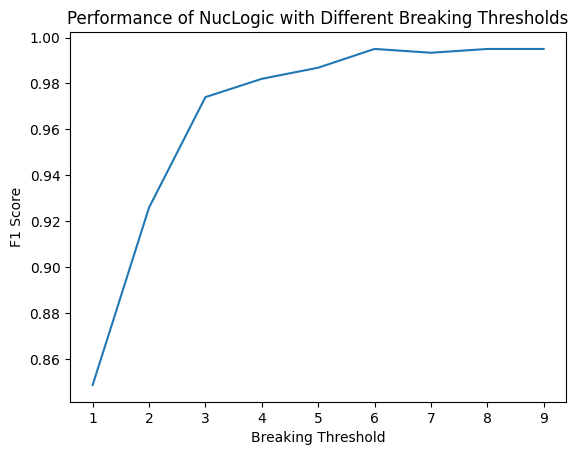

In [17]:
import matplotlib.pyplot as plt
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.stitch_3d import stitch_3d

segmented_2d = tifffile.imread(os.path.join(output_directory, f"synthetic_segmented_2d.tif"))
realistic_volume = tifffile.imread(os.path.join(output_directory, "synthetic_organoid.tif"))
step = 1
f1_values = []
for breaking_threshold in np.arange(1,10,step):
    nuclogic = stitch_3d(segmented_2d, realistic_volume, breaking_threshold = breaking_threshold, scale=(2.5, 0.64, 0.64))
    f1 = centroid_accuracy(mask, nuclogic)["f1"]
    f1_values.append(f1)

plt.plot(np.arange(1,10,step), f1_values)
plt.xlabel("Breaking Threshold")
plt.ylabel("F1 Score")
plt.title("Performance of NucLogic with Different Breaking Thresholds")
plt.show()

Test on drosophila

In [ ]:
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
import importlib
import utils.stitch_3d
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.stitch_3d import stitch_3d
from utils.load_model import load_model
import time
import tifffile
import pandas as pd

names = ["Drosophila_1", "Drosophila_2"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"

scale = (1, 1, 1)

model = load_model(r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Drosophila_1\model\drosophila")
# model = load_model(
#     r"C:\Users\6331823\Local SSD\Train model cell segmentation\models\cell_segmentation_4"
# )

results = []
for name in names:
    input_directory = os.path.join(base_directory, name)

    image = tifffile.imread(os.path.join(input_directory, "data.tif"))

    start_time = time.time()
    mask = segment(image, model)
    tifffile.imwrite(
        os.path.join(input_directory, "2d_segmented_seg4.tif"),
        mask,
        compression="zlib",
        compressionargs={"level": 8},
    )
    mask = tifffile.imread(os.path.join(input_directory, "2d_segmented_seg4.tif"))
    segmentation_time = time.time() - start_time


    start_stitch_time = time.time()
    nuclogic = stitch_3d(
        mask,
        image,
        image_type_1="wt",
        breaking_threshold=6,
        scale=scale
    )
    end_time = time.time()
    nuclogic_time = end_time - start_time
    nuclogic_cellpose_time = start_stitch_time - start_time
    nuclogic_stitch_time = end_time - start_stitch_time
    tifffile.imwrite(
        os.path.join(input_directory, "3d_segmented_nuclogic_seg4.tif"),
        nuclogic,
        compression="zlib",
        compressionargs={"level": 8},
    )

    ground_truth = tifffile.imread(
        os.path.join(input_directory, "GroundTruth.tif")
    )

    nuclogic_results = (centroid_accuracy(ground_truth, nuclogic))
    print(f"centroid accuracy: {nuclogic_results}")
    print(
        f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(nuclogic)) - 1}"
    )

    print(f"Segmentation completed in {segmentation_time:.2f} seconds.")
    print(f"Stitching completed in {end_time - start_stitch_time:.2f} seconds.")
    print(f"Total nuclogic time: {end_time - start_time:.2f} seconds.")


    start_cp4 = time.time()
    cp4,_,_ = model.eval(
                    image,
                    diameter=None,
                    normalize=True,
                    flow3D_smooth=0.4,
                    invert=False,
                    resample=True,
                    do_3D=True,
                    z_axis=0
                )
    end_cp4 = time.time()
    cp4_time = end_cp4 - start_cp4

    tifffile.imwrite(
        os.path.join(input_directory, "3d_segmented_cp4.tif"),
        cp4,
        compression="zlib",
        compressionargs={"level": 8},
    )

    cp4_results = (centroid_accuracy(ground_truth, cp4))
    print(f"centroid accuracy: {cp4_results}")
    print(
        f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(cp4)) - 1}"
    )
    print(f"Cellpose 4 completed in {cp4_time:.2f} seconds with F1 of {cp4_results['f1']:.3f}.")
    print(f"Total nuclogic time: {nuclogic_time:.2f} seconds with F1 of {nuclogic_results['f1']:.3f}.")

    # save results of centroid accuracy and amount of cells to a tsv file

    results_df = pd.DataFrame(
        {
            "method": ["nuclogic", "cellpose4"],
            "f1": [nuclogic_results["f1"], cp4_results["f1"]],
            "precision": [nuclogic_results["precision"], cp4_results["precision"]],
            "recall": [nuclogic_results["recall"], cp4_results["recall"]],
            "actual_cells": [len(np.unique(ground_truth)) - 1, len(np.unique(ground_truth)) - 1],
            "predicted_cells": [len(np.unique(nuclogic)) - 1, len(np.unique(cp4)) - 1],
            "true_positives": [nuclogic_results["true_positives"], cp4_results["true_positives"]],
            "false_positives": [nuclogic_results["false_positives"], cp4_results["false_positives"]],
            "false_negatives": [nuclogic_results["false_negatives"], cp4_results["false_negatives"]],
            "merged_cells": [nuclogic_results["merged_cells"], cp4_results["merged_cells"]],
            "total_time": [nuclogic_time, cp4_time],
            "nuclogic_2d_time": [nuclogic_cellpose_time, 0],
            "stitching_time": [nuclogic_stitch_time, 0],
        }
    )
    results_df.insert(0, "sample", name) 
    results.append(results_df)
results_df = pd.concat(results, ignore_index=True)

results_df.to_csv(os.path.join(output_directory, "zebrafish_results_seg4.tsv"), sep="\t", index=False)

Using CUDA for processing.
loaded custom model: cell_segmentation_4
Starting 3D stitching process...
Creating unique mask for properties calculation...
Unique mask created with 62325 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 12114 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 2248 breaks.
    Iteration 2: Made 607 breaks.
    Iteration 3: Made 114 breaks.
    Iteration 4: Made 14 breaks.
    Iteration 5: Made 1 breaks.
Finding touching cell pairs...
Found 8409 pairs of touching cells.
Splitted 5185 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 48 small cells, and removed 1606 cells without suitable neighbors.
Final stitched mask has 13444 cells.
centroid accuracy: {'true_positives': 12078, 'false_negatives': 715, 'false_positives': 1366, 'merged_cells': 298, 'precision': 0.8983933353168699, 'recall': 0.944110060189166, 'f1': 0.9206845294812669, '

In [ ]:
import napari
import os
import tifffile
from napari.utils.colormaps import colormap_utils as cu
colormap = cu.label_colormap(num_colors=1024)

names = ["Drosophila_1"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
dir = os.path.join(base_directory, names[0])
image = tifffile.imread(os.path.join(dir, "data.tif"))
ground_truth = tifffile.imread(os.path.join(dir, "GroundTruth.tif"))
nuclogic = tifffile.imread(os.path.join(dir, "3d_segmented_nuclogic_trained.tif"))
cp4 = tifffile.imread(os.path.join(dir, "3d_segmented_cp4.tif"))
viewer = napari.Viewer(ndisplay=3)
viewer.grid.enabled = True
scale = (2.5, 0.43, 0.43)

y_half = slice(0, image.shape[1] // 2)
x_half = slice(0, image.shape[2] // 2)

viewer.add_image(image[y_half, x_half], scale=scale)    
viewer.add_labels(ground_truth[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(nuclogic[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(cp4[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)

viewer.reset_view()
viewing_angle = (0, 180, 90)
viewer.camera.angles = viewing_angle
# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
# viewer.theme = 'light'


# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
viewer.screenshot(path=os.path.join(output_directory, "drosophila_data.png"), canvas_only=True, scale = 2.2)

# Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.camera.center = (109.09719441054212, 99.90710855199106, 302.3227946123624)
viewer.camera.zoom   = 11.503409054721994
# @viewer.bind_key('c')  # press 'c' to capture camera state
# def print_camera(viewer):
#     print(f"viewer.camera.center = {viewer.camera.center}")
#     print(f"viewer.camera.angles = {viewer.camera.angles}")
#     print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

viewer.screenshot(path=os.path.join(output_directory, "drosophila_zoomed.png"), canvas_only=True, scale = 2)

NameError: name 'os' is not defined

C:\Users\6331823\AppData\Local\Temp\ipykernel_29420\2194222606.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=45, ha="right", rotation_mode="anchor")


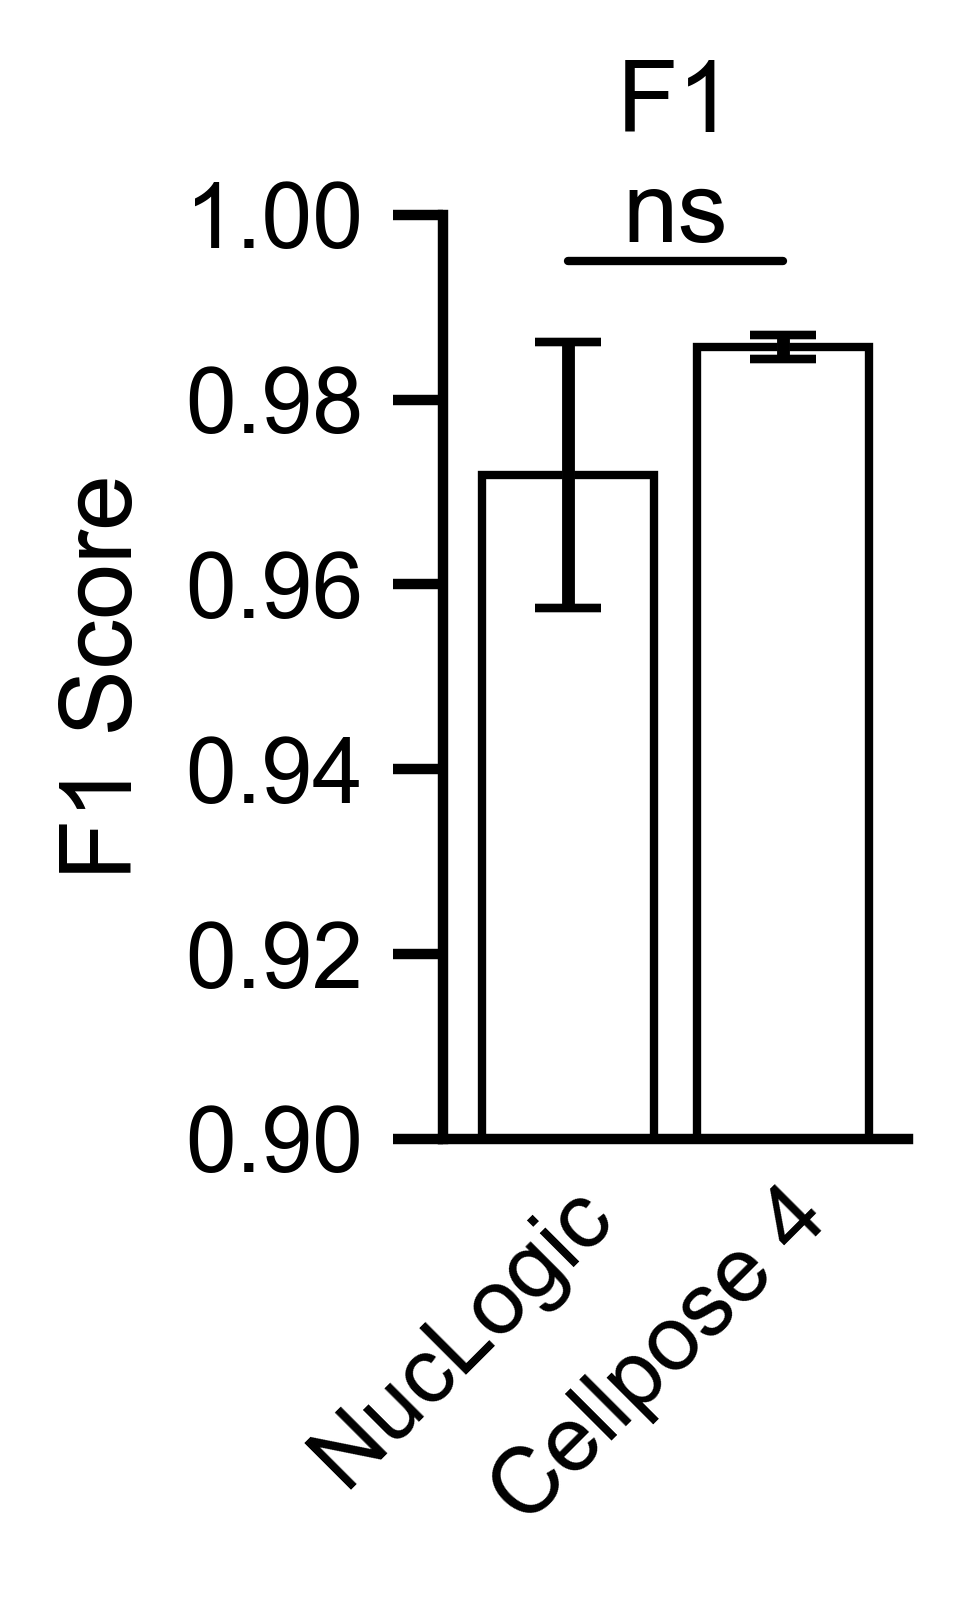

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator
import os
import numpy as np
from scipy.stats import ttest_ind

input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results = pd.read_csv(os.path.join(input_directory, "drosophila_results.tsv"), sep="\t")
methods = ["NucLogic", "Cellpose 4"]
results["method"] = results["method"].replace({"nuclogic": "NucLogic", "cellpose4": "Cellpose 4"})
metric = "f1"
sns.set_theme(context="notebook", style="white", rc={
    "text.color":       "black",   # generic text (annotations, legend)
    "axes.labelcolor":  "black",   # x/y axis labels
    "axes.titlecolor":  "black",   # titles
    "xtick.color":      "black",   # x tick MARKS + numbers
    "ytick.color":      "black",   # y tick MARKS + numbers
    "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
})
# mean + sd per method (sd needs >1 sample per method; otherwise NaN -> no error bar)  
cols = [metric]                     
agg = results.groupby("method")[cols].agg(["mean", "std"])

x = np.arange(len(methods))          # one group center per method
color =  "black"

fig, ax = plt.subplots(figsize=(1, 2), dpi=600)

# --- time bar on the RIGHT axis ---
means = [agg.loc[m, (metric, "mean")] for m in methods]
sds   = [agg.loc[m, (metric, "std")]  for m in methods]
ax.bar(x=methods, height=means, yerr=sds, capsize=4, linewidth=1,
        label="Time", color="white", edgecolor=color) # offset a little bit to the right so it doesn't overlap with the score bars
ax.errorbar(x=methods, y=means, yerr=sds, fmt='none', color="black", capsize=4)
ax.set_ylim(0.9, 1)
ax.set_ylabel("F1 Score")
ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
ax.set_xticklabels(methods, rotation=45, ha="right", rotation_mode="anchor")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("F1", pad=10)
ax.tick_params(left=True, bottom=False) 
ax.tick_params(axis="x", pad=-2)   # smaller/negative = labels move up
ax.margins(x=0.1)

nuclogic_values = results[results["method"] == "NucLogic"][metric]
cellpose_values = results[results["method"] == "Cellpose 4"][metric]
t_stat, p_value = ttest_ind(nuclogic_values, cellpose_values, equal_var=False)
# add significance stars if p-value < 0.0001
if p_value < 0.0001:
        text = '****'
elif p_value < 0.001:
        text = '***'
elif p_value < 0.01:
        text = '**'
elif p_value < 0.05:
        text = '*'
else:
        text = 'ns'
max_height = 0.995
ax.plot([0, 1], [max_height, max_height], color='black', linewidth=1)
ax.text(0.5, max_height , text, ha='center', va='bottom', fontsize=12)

figure_folder = os.path.join(r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures")
plt.savefig(os.path.join(figure_folder, "drosophila_results_f1.eps"), dpi=600, bbox_inches="tight")
plt.show()

C:\Users\6331823\AppData\Local\Temp\ipykernel_29420\490067524.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=45, ha="right", rotation_mode="anchor")


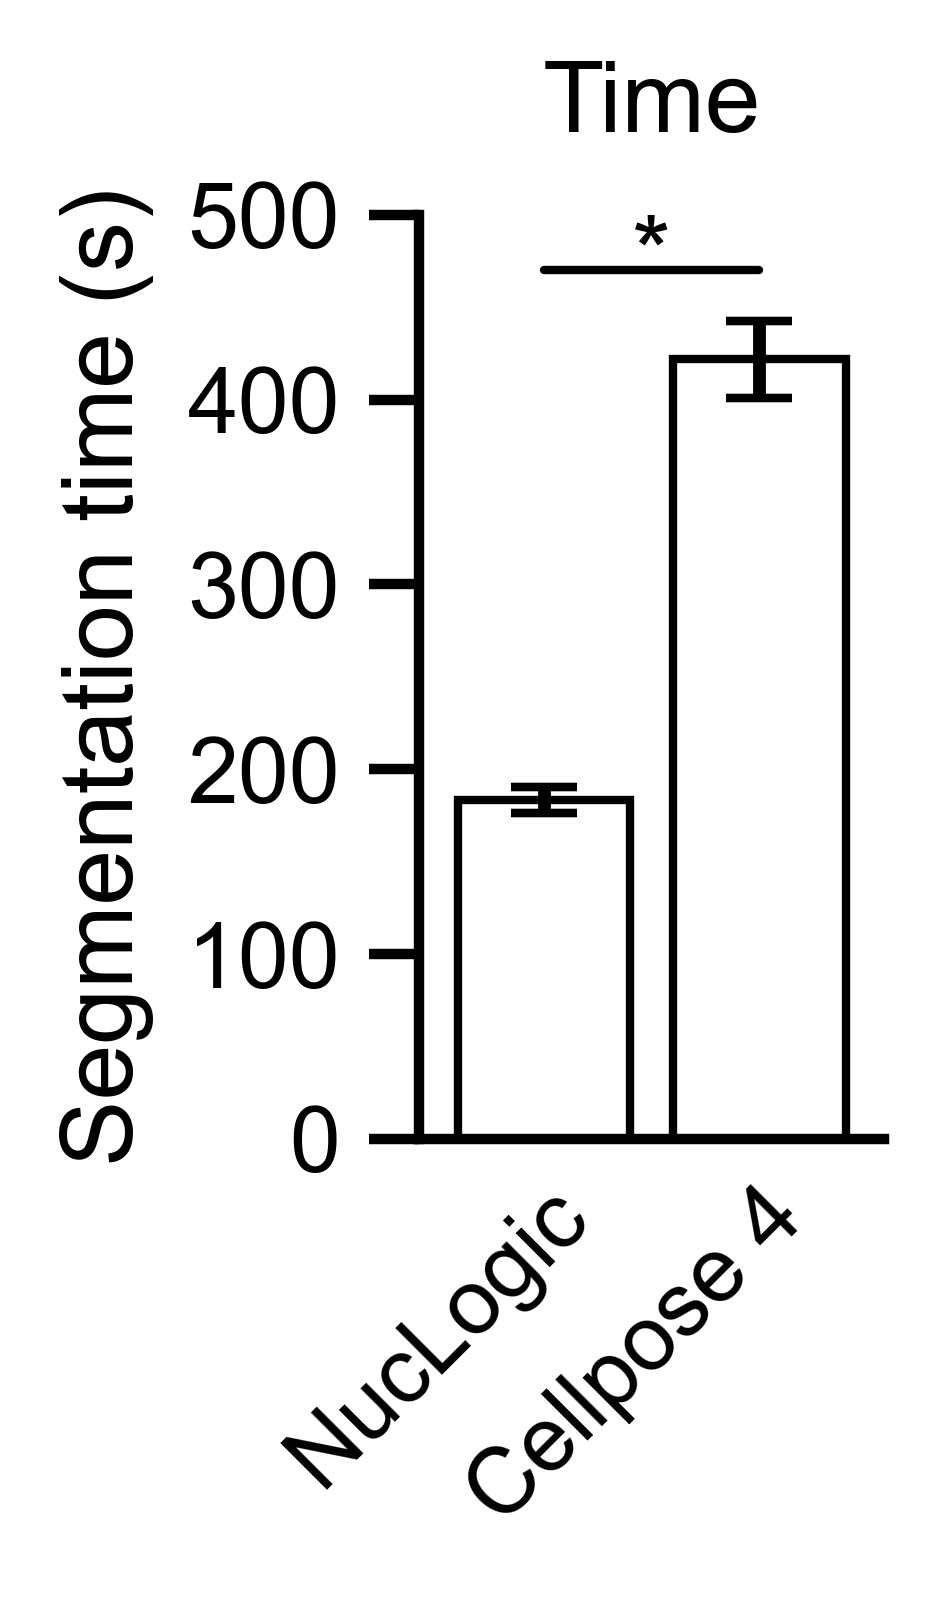

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator
import os
import numpy as np
from scipy.stats import ttest_ind

input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results = pd.read_csv(os.path.join(input_directory, "drosophila_results.tsv"), sep="\t")
methods = ["NucLogic", "Cellpose 4"]
results["method"] = results["method"].replace({"nuclogic": "NucLogic", "cellpose4": "Cellpose 4"})
time_metric = "total_time"
sns.set_theme(context="notebook", style="white", rc={
    "text.color":       "black",   # generic text (annotations, legend)
    "axes.labelcolor":  "black",   # x/y axis labels
    "axes.titlecolor":  "black",   # titles
    "xtick.color":      "black",   # x tick MARKS + numbers
    "ytick.color":      "black",   # y tick MARKS + numbers
    "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
})
# mean + sd per method (sd needs >1 sample per method; otherwise NaN -> no error bar)  
cols = [time_metric]                     
agg = results.groupby("method")[cols].agg(["mean", "std"])

x = np.arange(len(methods))          # one group center per method
color =  "black"

fig, ax = plt.subplots(figsize=(1, 2), dpi=600)

# --- time bar on the RIGHT axis ---
means = [agg.loc[m, (time_metric, "mean")] for m in methods]
sds   = [agg.loc[m, (time_metric, "std")]  for m in methods]
ax.bar(x=methods, height=means, yerr=sds, capsize=4, linewidth=1,
        label="Time", color="white", edgecolor=color) # offset a little bit to the right so it doesn't overlap with the score bars
ax.errorbar(x=methods, y=means, yerr=sds, fmt='none', color="black", capsize=4)
ax.set_ylim(0, 500)
ax.set_ylabel("Segmentation time (s)")
ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
ax.set_xticklabels(methods, rotation=45, ha="right", rotation_mode="anchor")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("Time", pad=10)
ax.tick_params(left=True, bottom=False) 
ax.tick_params(axis="x", pad=-2)   # smaller/negative = labels move up
ax.margins(x=0.1)

nuclogic_values = results[results["method"] == "NucLogic"][time_metric]
cellpose_values = results[results["method"] == "Cellpose 4"][time_metric]
t_stat, p_value = ttest_ind(nuclogic_values, cellpose_values, equal_var=False)
# add significance stars if p-value < 0.0001
if p_value < 0.0001:
        text = '****'
elif p_value < 0.001:
        text = '***'
elif p_value < 0.01:
        text = '**'
elif p_value < 0.05:
        text = '*'
max_height = 470
ax.plot([0, 1], [max_height, max_height], color='black', linewidth=1)
ax.text(0.5, max_height - 20, text, ha='center', va='bottom', fontsize=12)

figure_folder = os.path.join(r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures")
plt.savefig(os.path.join(figure_folder, "drosophila_results_time.eps"), dpi=600, bbox_inches="tight")
plt.show()

Zebrafish

In [25]:
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
import importlib
import utils.stitch_3d
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.stitch_3d import stitch_3d
from utils.load_model import load_model
import time
import tifffile
import pandas as pd

# names = ["Drosophila_1", "Drosophila_2"]
names = ["Zebrafish_1"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"

model = load_model(
    r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Zebrafish_1\model\models\zebrafish"
)
# model = load_model(
#     r"C:\Users\6331823\Local SSD\Train model cell segmentation\models\cell_segmentation_4"
# )

results = []
for name in names:
    if name == "Zebrafish_1":
        scale = (2.5, 0.43, 0.43)
    elif name == "Zebrafish_2":
        scale = (1,1,1)
    input_directory = os.path.join(base_directory, name)

    image = tifffile.imread(os.path.join(input_directory, "data.tif"))

    start_time = time.time()
    mask = segment(image, model)
    tifffile.imwrite(
        os.path.join(input_directory, "2d_segmented_trained.tif"),
        mask,
        compression="zlib",
        compressionargs={"level": 8},
    )
    mask = tifffile.imread(os.path.join(input_directory, "2d_segmented_trained.tif"))
    segmentation_time = time.time() - start_time


    start_stitch_time = time.time()
    nuclogic = stitch_3d(
        mask,
        image,
        image_type_1="wt",
        breaking_threshold=6,
        scale=scale
    )
    end_time = time.time()
    nuclogic_time = end_time - start_time
    nuclogic_cellpose_time = start_stitch_time - start_time
    nuclogic_stitch_time = end_time - start_stitch_time
    tifffile.imwrite(
        os.path.join(input_directory, "3d_segmented_nuclogic_trained.tif"),
        nuclogic,
        compression="zlib",
        compressionargs={"level": 8},
    )
    nuclogic = tifffile.imread(os.path.join(input_directory, "3d_segmented_nuclogic_trained.tif"))

    ground_truth = tifffile.imread(
        os.path.join(input_directory, "GroundTruth.tif")
    )

    nuclogic_results = (centroid_accuracy(ground_truth, nuclogic))
    print(f"centroid accuracy: {nuclogic_results}")
    print(
        f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(nuclogic)) - 1}"
    )

    print(f"Segmentation completed in {segmentation_time:.2f} seconds.")
    print(f"Stitching completed in {end_time - start_stitch_time:.2f} seconds.")
    print(f"Total nuclogic time: {end_time - start_time:.2f} seconds.")


    start_cp4 = time.time()
    cp4,_,_ = model.eval(
                    image,
                    diameter=None,
                    normalize=True,
                    flow3D_smooth=0.4,
                    invert=False,
                    resample=True,
                    do_3D=True,
                    z_axis=0,
                    min_size=150,
                )
    end_cp4 = time.time()
    cp4_time = end_cp4 - start_cp4

    tifffile.imwrite(
        os.path.join(input_directory, "3d_segmented_cp4_trained.tif"),
        cp4,
        compression="zlib",
        compressionargs={"level": 8},
    )

    cp4_results = (centroid_accuracy(ground_truth, cp4))
    print(f"centroid accuracy: {cp4_results}")
    print(
        f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(cp4)) - 1}"
    )
    print(f"Cellpose 4 completed in {cp4_time:.2f} seconds with F1 of {cp4_results['f1']:.3f}.")
    print(f"Total nuclogic time: {nuclogic_time:.2f} seconds with F1 of {nuclogic_results['f1']:.3f}.")

    # save results of centroid accuracy and amount of cells to a tsv file

    results_df = pd.DataFrame(
        {
            "method": ["nuclogic", "cellpose4"],
            "f1": [nuclogic_results["f1"], cp4_results["f1"]],
            "precision": [nuclogic_results["precision"], cp4_results["precision"]],
            "recall": [nuclogic_results["recall"], cp4_results["recall"]],
            "actual_cells": [len(np.unique(ground_truth)) - 1, len(np.unique(ground_truth)) - 1],
            "predicted_cells": [len(np.unique(nuclogic)) - 1, len(np.unique(cp4)) - 1],
            "true_positives": [nuclogic_results["true_positives"], cp4_results["true_positives"]],
            "false_positives": [nuclogic_results["false_positives"], cp4_results["false_positives"]],
            "false_negatives": [nuclogic_results["false_negatives"], cp4_results["false_negatives"]],
            "merged_cells": [nuclogic_results["merged_cells"], cp4_results["merged_cells"]],
            "total_time": [nuclogic_time, cp4_time],
            "nuclogic_2d_time": [nuclogic_cellpose_time, 0],
            "stitching_time": [nuclogic_stitch_time, 0],
        }
    )
    results_df.insert(0, "sample", name) 
    results.append(results_df)
results_df = pd.concat(results, ignore_index=True)

results_df.to_csv(os.path.join(output_directory, "zebrafish_results_trained.tsv"), sep="\t", index=False)

Using CUDA for processing.
loaded custom model: zebrafish
Starting 3D stitching process...
Creating unique mask for properties calculation...
Unique mask created with 63993 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 12988 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 2342 breaks.
    Iteration 2: Made 705 breaks.
    Iteration 3: Made 132 breaks.
    Iteration 4: Made 12 breaks.
    Iteration 5: Made 2 breaks.
Finding touching cell pairs...
Found 9181 pairs of touching cells.
Splitted 5773 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 59 small cells, and removed 2946 cells without suitable neighbors.
Final stitched mask has 13176 cells.
centroid accuracy: {'true_positives': 11989, 'false_negatives': 804, 'false_positives': 1187, 'merged_cells': 509, 'precision': 0.9099119611414693, 'recall': 0.9371531306183069, 'f1': 0.923331664677115, 'voxel_dice

In [11]:
import napari
import os
import tifffile
from napari.utils.colormaps import colormap_utils as cu
colormap = cu.label_colormap(num_colors=1024)
colormap_seg = {0: '', 1: 'green', 2: 'magenta', 3: 'cyan'}

# names = ["Zebrafish_1"]
# base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
# dir = os.path.join(base_directory, names[0])
# image = tifffile.imread(os.path.join(dir, "data.tif"))
# ground_truth = tifffile.imread(os.path.join(dir, "GroundTruth.tif"))
# nuclogic = tifffile.imread(os.path.join(dir, "3d_segmented_nuclogic_trained.tif"))
# cp4 = tifffile.imread(os.path.join(dir, "3d_segmented_cp4.tif"))





# def color_mask(mask, gt, tp_list, fp_list, fn_list):
#     # mask-based classes (tp=1, fp=2)
#     lut = np.zeros(int(mask.max()) + 1, dtype=np.uint8)
#     lut[np.asarray(tp_list, dtype=int)] = 1
#     lut[np.asarray(fp_list, dtype=int)] = 2
#     colored = lut[mask]

#     # fn comes from gt, painted on top
#     fn_lut = np.zeros(int(gt.max()) + 1, dtype=np.uint8)
#     fn_lut[np.asarray(fn_list, dtype=int)] = 3
#     colored[fn_lut[gt] == 3] = 3
#     return colored

# nuclogic_results = (centroid_accuracy(ground_truth, nuclogic))
# nuclogic_colored = color_mask(nuclogic, ground_truth, nuclogic_results["tp_list"], nuclogic_results["fp_list"], nuclogic_results["fn_list"])
# cp4_results = (centroid_accuracy(ground_truth, cp4))
# cp4_colored = color_mask(cp4, ground_truth, cp4_results["tp_list"], cp4_results["fp_list"], cp4_results["fn_list"])

viewer = napari.Viewer(ndisplay=3)
viewer.grid.enabled = True
scale = (2.5, 0.43, 0.43)

y_half = slice(0, image.shape[1] // 2)
x_half = slice(0, image.shape[2] // 2)

viewer.add_image(image[y_half, x_half], scale=scale)    
viewer.add_labels(ground_truth[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(nuclogic_colored[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap_seg, opacity=1)
viewer.add_labels(cp4_colored[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap_seg, opacity=1)

viewer.reset_view()
viewing_angle = (180, 0, 0)
viewer.camera.angles = viewing_angle
# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
# viewer.theme = 'light'


# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
viewer.screenshot(path=os.path.join(output_directory, "zebrafish_data.png"), canvas_only=True, scale = 1.2)

# # Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.camera.center = (16.796264343669097, 237.4340231835281, 402.7615460461847)
viewer.camera.zoom   = 11.503409054721994
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

viewer.screenshot(path=os.path.join(output_directory, "zebrafish_zoomed.png"), canvas_only=True, scale = 1.3)

c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


array([[[ 70,  70,  70, 255],
        [ 70,  70,  70, 255],
        [ 69,  69,  69, 255],
        ...,
        [204,  99,  84, 255],
        [204,  99,  84, 255],
        [173,  84,  71, 255]],

       [[ 69,  69,  69, 255],
        [ 69,  69,  69, 255],
        [ 69,  69,  69, 255],
        ...,
        [204,  99,  84, 255],
        [204,  99,  84, 255],
        [173,  84,  71, 255]],

       [[ 69,  69,  69, 255],
        [ 69,  69,  69, 255],
        [ 69,  69,  69, 255],
        ...,
        [204,  99,  84, 255],
        [204,  99,  84, 255],
        [173,  84,  71, 255]],

       ...,

       [[  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        ...,
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255]],

       [[  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        ...,
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255]],

       [[  0

C:\Users\6331823\AppData\Local\Temp\ipykernel_29420\564425438.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=45, ha="right", rotation_mode="anchor")


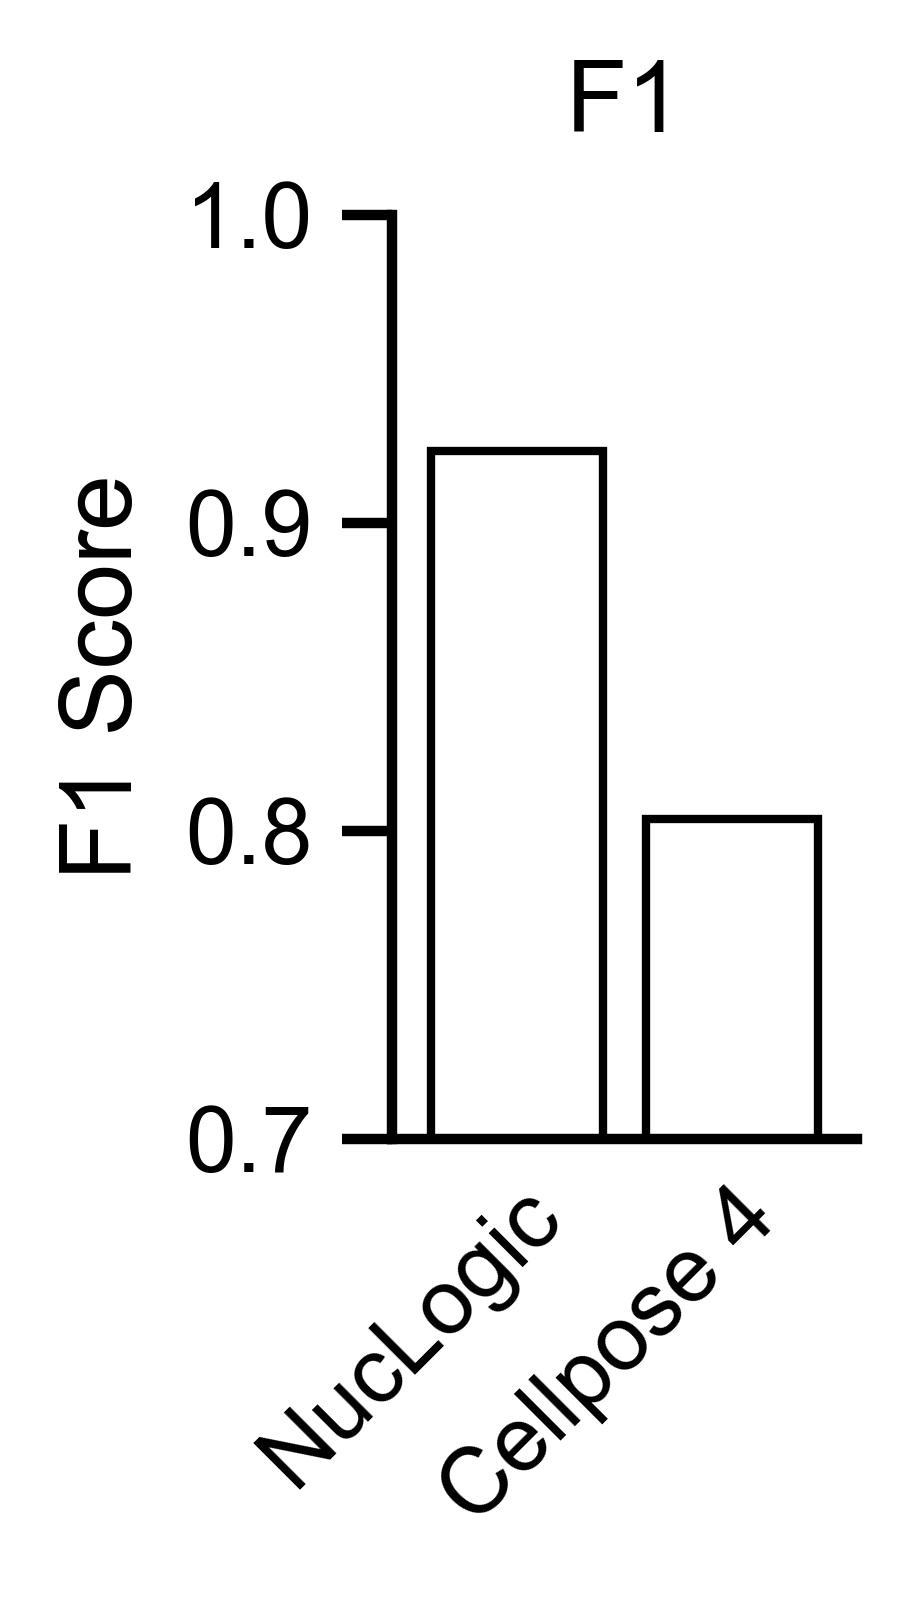

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator
import os
import numpy as np
from scipy.stats import ttest_ind

input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results = pd.read_csv(os.path.join(input_directory, "zebrafish_results_trained.tsv"), sep="\t")
methods = ["NucLogic", "Cellpose 4"]
results["method"] = results["method"].replace({"nuclogic": "NucLogic", "cellpose4": "Cellpose 4"})
sns.set_theme(context="notebook", style="white", rc={
    "text.color":       "black",   # generic text (annotations, legend)
    "axes.labelcolor":  "black",   # x/y axis labels
    "axes.titlecolor":  "black",   # titles
    "xtick.color":      "black",   # x tick MARKS + numbers
    "ytick.color":      "black",   # y tick MARKS + numbers
    "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
})
# mean + sd per method (sd needs >1 sample per method; otherwise NaN -> no error bar)  

fig, ax = plt.subplots(figsize=(1, 2), dpi=600)

# --- time bar on the RIGHT axis ---
ax.bar(results["method"], results["f1"], capsize=4, linewidth=1,
        label="Time", color="white", edgecolor=color) # offset a little bit to the right so it doesn't overlap with the score bars
ax.set_ylim(0.7, 1)
ax.set_ylabel("F1 Score")

ax.set_xticklabels(methods, rotation=45, ha="right", rotation_mode="anchor")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("F1", pad=10)
ax.tick_params(left=True, bottom=False) 
ax.tick_params(axis="x", pad=-2)   # smaller/negative = labels move up
ax.margins(x=0.1)
ax.yaxis.set_ticks([0.7, 0.8, 0.9, 1])

figure_folder = os.path.join(r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures")
plt.savefig(os.path.join(figure_folder, "zebrafish_results_f1.eps"), dpi=600, bbox_inches="tight")
plt.show()

0     650.135516
1    2190.747435
Name: total_time, dtype: float64


C:\Users\6331823\AppData\Local\Temp\ipykernel_29420\652147048.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=45, ha="right", rotation_mode="anchor")


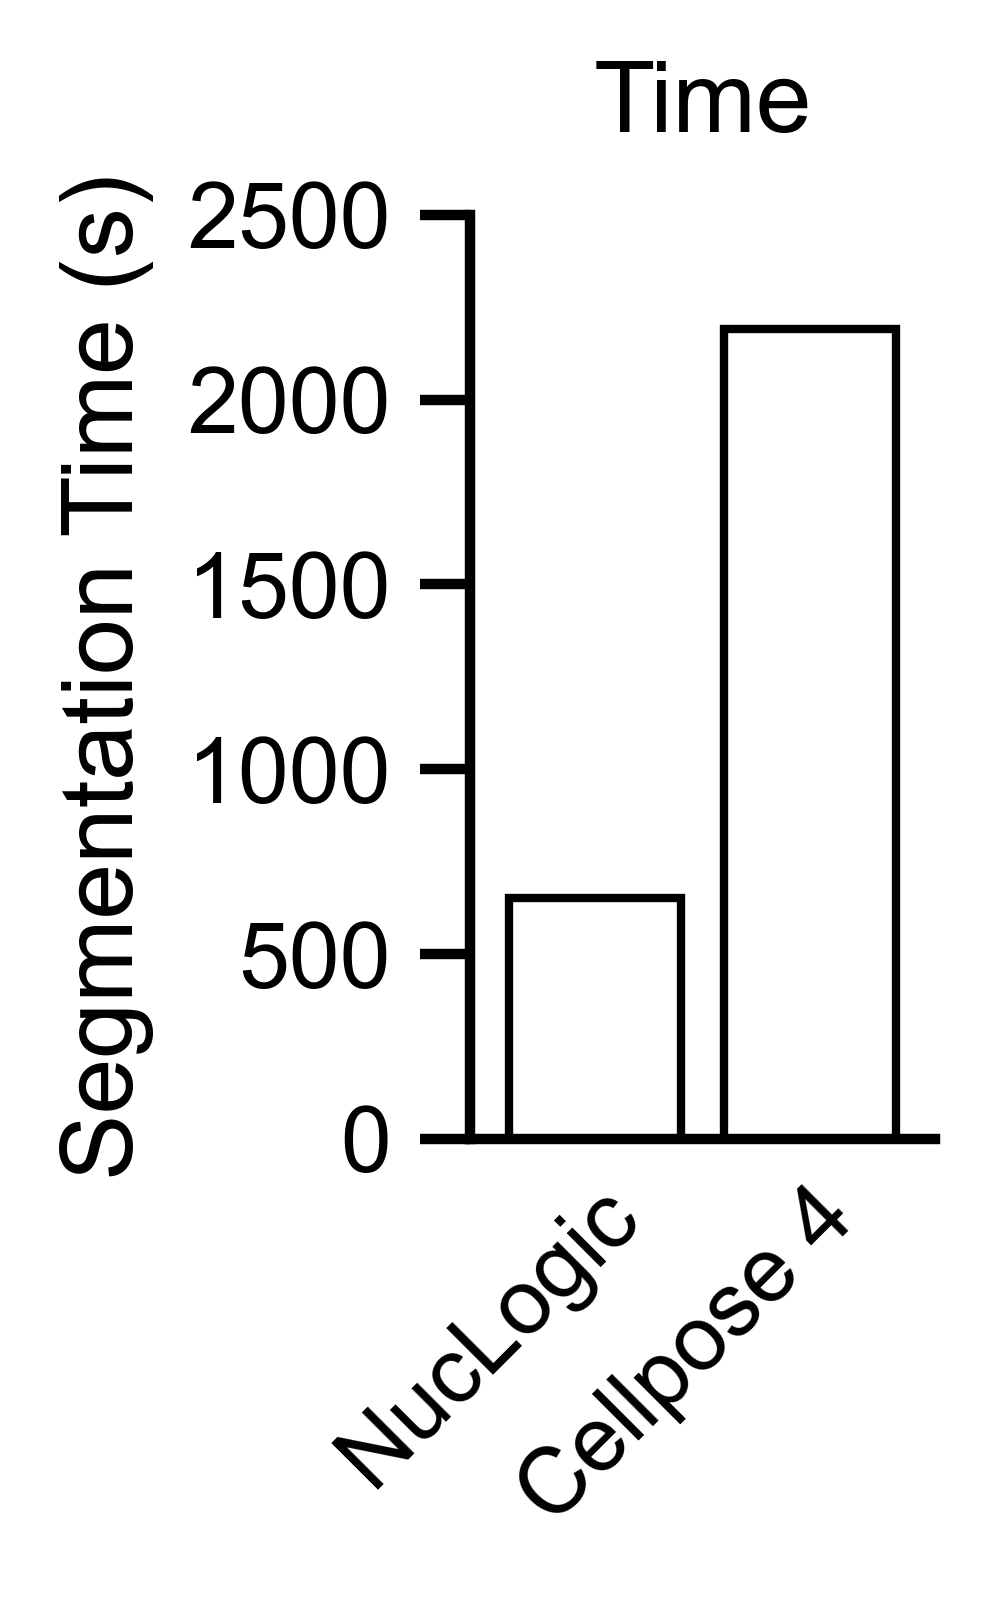

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator
import os
import numpy as np
from scipy.stats import ttest_ind

input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results = pd.read_csv(os.path.join(input_directory, "zebrafish_results_trained.tsv"), sep="\t")
methods = ["NucLogic", "Cellpose 4"]
results["method"] = results["method"].replace({"nuclogic": "NucLogic", "cellpose4": "Cellpose 4"})
sns.set_theme(context="notebook", style="white", rc={
    "text.color":       "black",   # generic text (annotations, legend)
    "axes.labelcolor":  "black",   # x/y axis labels
    "axes.titlecolor":  "black",   # titles
    "xtick.color":      "black",   # x tick MARKS + numbers
    "ytick.color":      "black",   # y tick MARKS + numbers
    "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
})
# mean + sd per method (sd needs >1 sample per method; otherwise NaN -> no error bar)  

fig, ax = plt.subplots(figsize=(1, 2), dpi=600)

# --- time bar on the RIGHT axis ---
print(results["total_time"])
ax.bar(results["method"], results["total_time"], capsize=4, linewidth=1,
        label="Time", color="white", edgecolor=color) # offset a little bit to the right so it doesn't overlap with the score bars
ax.set_ylim(0, 2500)
ax.set_ylabel("Segmentation Time (s)")
ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
ax.set_xticklabels(methods, rotation=45, ha="right", rotation_mode="anchor")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("Time", pad=10)
ax.tick_params(left=True, bottom=False) 
ax.tick_params(axis="x", pad=-2)   # smaller/negative = labels move up
ax.margins(x=0.1)

figure_folder = os.path.join(r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures")
plt.savefig(os.path.join(figure_folder, "zebrafish_results_total_time.eps"), dpi=600, bbox_inches="tight")
plt.show()

C. Elegans

In [ ]:
# concatenate movie
import os
import numpy as np
import tifffile

input_directory = r"C:\Users\6331823\Downloads\nih-ls"
sample = "nih_diSPIM_deconv_1"

voxel_size = (0.5, 0.1625, 0.1625)  # in micrometers

folder = os.path.join(input_directory, sample, "images")
images_sorted = sorted(os.listdir(folder))

movie = []
for image in images_sorted:
    if image.endswith(".tif"):
        img = tifffile.imread(os.path.join(folder, image))
        movie.append(img)

movie = np.stack(movie, axis=0)

tifffile.imwrite(os.path.join(input_directory, sample, f"{sample}.tif"), 
                 movie, 
                 bigtiff=True,
                 resolution=(
                    1 / voxel_size[2],
                    1 / voxel_size[1],
                 ),
                 metadata={
                    "unit": "um",
                    "axes": "TZCYX",
                    "spacing": voxel_size[0],
                    "finterval": time_interval,
                    "tunit": "h",
                 },
                 compression="zlib", 
                 compressionargs={"level": 8}
                 )

Adding image nih_diSPIM_deconv_1_t000.tif to movie with shape (240, 244, 410)
Adding image nih_diSPIM_deconv_1_t001.tif to movie with shape (240, 244, 410)
Adding image nih_diSPIM_deconv_1_t002.tif to movie with shape (240, 244, 410)
Adding image nih_diSPIM_deconv_1_t003.tif to movie with shape (240, 244, 410)
Adding image nih_diSPIM_deconv_1_t004.tif to movie with shape (240, 244, 410)
Adding image nih_diSPIM_deconv_1_t005.tif to movie with shape (240, 244, 410)
Adding image nih_diSPIM_deconv_1_t006.tif to movie with shape (240, 244, 410)
Adding image nih_diSPIM_deconv_1_t007.tif to movie with shape (240, 244, 410)
Adding image nih_diSPIM_deconv_1_t008.tif to movie with shape (240, 244, 410)
Adding image nih_diSPIM_deconv_1_t009.tif to movie with shape (240, 244, 410)
Adding image nih_diSPIM_deconv_1_t010.tif to movie with shape (240, 244, 410)
Adding image nih_diSPIM_deconv_1_t011.tif to movie with shape (240, 244, 410)
Adding image nih_diSPIM_deconv_1_t012.tif to movie with shape (2

KeyboardInterrupt: 

In [27]:

import napari
import tifffile
import os
import numpy as np

input_directory = r"C:\Users\6331823\Downloads\nih-ls"
sample = "nih_diSPIM_deconv_1"
movie = tifffile.imread(os.path.join(input_directory, sample, f"{sample}_gaus.tif"))
output = r"C:\Users\6331823\Downloads\nih-ls\nih_diSPIM_deconv_1\model"

# pick 30 random slices from movie
amount_of_slices = movie.shape[0]*movie.shape[1]
random_indices = np.random.choice(amount_of_slices, size=30, replace=False)
for index in random_indices:
    t = index // movie.shape[0]
    z = index % movie.shape[0]
    slice = movie[z, t, :, :]
    tifffile.imwrite(os.path.join(output, f"slice_{t}_{z}.tif"), slice, compression="zlib", compressionargs={"level": 8})

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\6331823\\Downloads\\nih-ls\\nih_diSPIM_deconv_1\\nih_diSPIM_deconv_1_gaus.tif'

In [17]:
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
import importlib
import utils.stitch_3d
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.stitch_3d import stitch_3d
from utils.load_model import load_model
import time
import tifffile
import pandas as pd

model = load_model(
    r"C:\Users\6331823\Downloads\nih-ls\nih_diSPIM_deconv_1\model\c elegans"
)


input_directory = r"C:\Users\6331823\Downloads\nih-ls"
sample = "nih_diSPIM_deconv_1"
# movie = tifffile.imread(os.path.join(input_directory, sample, f"{sample}.tif"))
movie = gaus_movie
print(movie.shape)

for t in range(movie.shape[0]):
    time0 = time.time()
    segmented = segment(movie[t, :, :, :], model)
    print(f"Segmentation of timepoint {t} completed in {time.time() - time0:.2f} seconds.")
    segmented = stitch_3d(segmented, movie[t, :, :, :], breaking_threshold=6, scale=(0.1625, 0.1625, 0.1625))
    print(f"Full processing of timepoint {t} completed in {time.time() - time0:.2f} seconds.")
    tifffile.imwrite(os.path.join(input_directory, sample, f"segmented_{t}.tif"), segmented, compression="zlib", compressionargs={"level": 8})





Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	win32 
python version: 	3.11.13 
torch version:  	2.8.0+cu128! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 


Using CUDA for processing.
loaded custom model: c elegans
(10, 240, 244, 410)
Segmentation of timepoint 0 completed in 44.96 seconds.
Starting 3D stitching process...
Creating unique mask for properties calculation...
Unique mask created with 482 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 23 cells formed.
Starting iterative breaking of cells
Finding touching cell pairs...
Found 0 pairs of touching cells.
Splitted 0 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 0 small cells, and removed 3 cells without suitable neighbors.
Final stitched mask has 20 cells.
Full processing of timep

KeyboardInterrupt: 

In [19]:
import napari
import tifffile
import numpy as np
import os
viewer = napari.Viewer(ndisplay=3)
scale = (0.1625, 0.1625, 0.1625)

input_directory = r"C:\Users\6331823\Downloads\nih-ls"
sample = "nih_diSPIM_deconv_1"

# movie = tifffile.imread(os.path.join(input_directory, sample, f"{sample}.tif"))
# segmented = tifffile.imread(os.path.join(input_directory, sample, f"segmented_0.tif"))
viewer.add_image(gaus_movie[0], scale=scale, colormap="Greys")
viewer.add_labels(segmented, scale=scale, iso_gradient_mode="smooth", opacity=1)

<Labels layer 'segmented' at 0x277a67f8690>

In [71]:
from skimage import filters
from scipy import ndimage
import tifffile
import os
import napari
input_directory = r"C:\Users\6331823\Downloads\nih-ls"
movie = tifffile.imread(os.path.join(input_directory, sample, sample, f"{sample}.tif"))

gaus_movie = []
filtered_movie = []
filtered_gaus_movie = []
for t in range(movie.shape[0]):
    print(f"Processing timepoint {t}...")
    gaus_minimal = ndimage.gaussian_filter(movie[t], sigma=0.5)
    gaus = ndimage.gaussian_filter(movie[t], sigma=5)
    gaus_movie.append(gaus)
    threshold = np.median(gaus) + np.std(gaus)
    print(f"Threshold for timepoint {t}: {threshold}")
    filtered_gaus = np.where(gaus > threshold, gaus_minimal, 0)
    filtered_gaus_movie.append(filtered_gaus)

# gaus_movie = np.stack(gaus_movie, axis=0)
filtered_gaus_movie = np.stack(filtered_gaus_movie, axis=0)
filtered_gaus_movie = np.expand_dims(filtered_gaus_movie, axis=2)  # add channel dimension
voxel_size = (0.1625, 0.1625, 0.1625)  # in micrometers

# viewer = napari.Viewer(ndisplay=3)
# scale = (0.1625, 0.1625, 0.1625)
# viewer.add_image(gaus_movie, scale=scale)
# viewer.add_image(filtered_gaus_movie, scale=scale)
tifffile.imwrite(os.path.join(input_directory, sample, f"{sample}_gaus.tif"), 
                 filtered_gaus_movie, 
                 imagej=True,
                 resolution=(
                    1 / voxel_size[2],
                    1 / voxel_size[1],
                 ),
                 metadata={
                    "unit": "um",
                    "axes": "TZCYX",
                    "spacing": voxel_size[0],
                    "finterval": 1.5,
                    "tunit": "min",
                 },
                 compression="zlib", 
                 compressionargs={"level": 4}
                 )

Processing timepoint 0...
Threshold for timepoint 0: 13.793957543710308
Processing timepoint 1...
Threshold for timepoint 1: 11.148165025375981
Processing timepoint 2...
Threshold for timepoint 2: 9.4508842798122
Processing timepoint 3...
Threshold for timepoint 3: 8.85959471796713
Processing timepoint 4...
Threshold for timepoint 4: 7.971471975290426
Processing timepoint 5...
Threshold for timepoint 5: 6.873715357995137
Processing timepoint 6...
Threshold for timepoint 6: 6.52714120801566
Processing timepoint 7...
Threshold for timepoint 7: 4.409746185287063
Processing timepoint 8...
Threshold for timepoint 8: 6.2587135278308805
Processing timepoint 9...
Threshold for timepoint 9: 6.589462339389506
Processing timepoint 10...
Threshold for timepoint 10: 7.910184411269962
Processing timepoint 11...
Threshold for timepoint 11: 13.076071333560837
Processing timepoint 12...
Threshold for timepoint 12: 11.225157886467874
Processing timepoint 13...
Threshold for timepoint 13: 12.895338935789

In [28]:
movie = tifffile.imread(os.path.join(input_directory, sample,  f"{sample}_gaus.tif"))
print(movie.shape)

(400, 240, 244, 410)


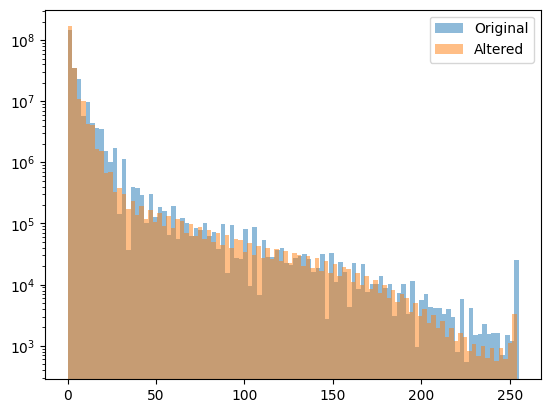

In [11]:
import matplotlib.pyplot as plt

plt.hist(sep_movie.flatten(), bins=100, alpha=0.5, label='Original')
plt.hist(altered.flatten(), bins=100, alpha=0.5, label='Altered')
plt.yscale('log')
plt.legend()
plt.show()

In [5]:
segmented.shape

(400, 166, 167, 343)

In [6]:
from skimage import filters
from scipy import ndimage
import tifffile
import os
import napari
from imaris_ims_file_reader.ims import ims

input_directory = r"C:\Users\6331823\Downloads\nih-ls"
sample = "nih_diSPIM_deconv_1"
name = f"{sample}_gaus"
movie = ims(os.path.join(input_directory, sample, name, f"{name}_cropped.ims"))
segmented = tifffile.imread(os.path.join(input_directory, sample, name, f"{name}_segmented.tif"))

viewer = napari.Viewer(ndisplay=3)
scale = (0.1625, 0.1625, 0.1625)
viewer.add_image(movie[:,0], scale=scale)
viewer.add_labels(segmented, scale=scale, iso_gradient_mode="smooth", opacity=1)

Opening readonly file: C:\Users\6331823\Downloads\nih-ls\nih_diSPIM_deconv_1\nih_diSPIM_deconv_1_gaus\nih_diSPIM_deconv_1_gaus_cropped.ims 



c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\imaris_ims_file_reader\ims.py:128: UserWarning: HistogramMax value is not present for resolution 2, time 399, channel 0. 
                              This may cause compatibility issues with programs that use imaris_ims_file_reader
  warnings.warn(warntxt)
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\imaris_ims_file_reader\ims.py:134: UserWarning: HistogramMin value is not present for resolution 2, time 399, channel 0.
                              This may cause compatibility issues with programs that use imaris_ims_file_reader
  warnings.warn(warntxt)


<Labels layer 'segmented' at 0x240a517b590>

In [7]:
pip install pynrrd

Note: you may need to restart the kernel to use updated packages.


Emmanuel zebrafish

In [ ]:
import napari
import nrrd
import numpy as np


image, header = nrrd.read(r"C:\Users\6331823\Local SSD\EML_zebrafish\MF59_r0c3.nrrd")
image = np.transpose(image, (2, 1, 0))  # transpose to ZYX order
seg, header = nrrd.read(r"C:\Users\6331823\Local SSD\EML_zebrafish\MF59_masks_crop.nrrd")
seg = np.transpose(seg, (2, 1, 0))  # transpose to ZYX order

viewer = napari.Viewer(ndisplay=3)
viewer.add_image(image, scale=(0.43, 0.23, 0.23))
viewer.add_labels(seg, scale=(0.43, 0.23, 0.23), iso_gradient_mode="smooth", opacity=1)
# random_indices = np.random.choice(image.shape[0], size=10, replace=False)
# for index in random_indices:
#     slice = image[index, :, :]
#     tifffile.imwrite(os.path.join(r"C:\Users\6331823\Local SSD\EML_zebrafish\model", f"slice_{index}.tif"), slice, compression="zlib", compressionargs={"level": 8})


<Labels layer 'seg' at 0x2410f6e4890>

In [3]:
import nrrd
import numpy as np
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
import importlib
import utils.stitch_3d
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.stitch_3d import stitch_3d
from utils.load_model import load_model
import time
import pandas as pd
import tifffile

input_directory = r"C:\Users\6331823\Local SSD\EML_zebrafish"
names = ["MF59_r0c3.nrrd"]

scale = (0.43, 0.23, 0.23)  # in micrometers



model = load_model(
    os.path.join(input_directory, "model", "zebrafish_lightsheet")
)

results = []
for name in names:
    image, header = nrrd.read(os.path.join(input_directory, name))
    image = np.transpose(image, (2, 1, 0))  # transpose to ZYX order

    start_time = time.time()
    # mask = segment(image, model)
    # tifffile.imwrite(
    #     os.path.join(input_directory, "2d_segmented.tif"),
    #     mask,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )
    mask = tifffile.imread(os.path.join(input_directory, "2d_segmented.tif"))
    segmentation_time = time.time() - start_time


    start_stitch_time = time.time()
    nuclogic = stitch_3d(
        mask,
        image,
        image_type_1="wt",
        breaking_threshold=6,
        scale=scale
    )
    end_time = time.time()
    nuclogic_time = end_time - start_time
    nuclogic_cellpose_time = start_stitch_time - start_time
    nuclogic_stitch_time = end_time - start_stitch_time
    tifffile.imwrite(
        os.path.join(input_directory, "3d_segmented_nuclogic.tif"),
        nuclogic,
        compression="zlib",
        compressionargs={"level": 8},
    )
    nuclogic = tifffile.imread(os.path.join(input_directory, "3d_segmented_nuclogic.tif"))

    ground_truth, header = nrrd.read(
        os.path.join(input_directory, "MF59_masks_crop.nrrd")
    )
    ground_truth = np.transpose(ground_truth, (2, 1, 0))  # transpose to ZYX order

    nuclogic_results = (centroid_accuracy(ground_truth, nuclogic))
    print(f"centroid accuracy: {nuclogic_results}")
    print(
        f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(nuclogic)) - 1}"
    )

    print(f"Segmentation completed in {segmentation_time:.2f} seconds.")
    print(f"Stitching completed in {end_time - start_stitch_time:.2f} seconds.")
    print(f"Total nuclogic time: {end_time - start_time:.2f} seconds.")


    start_cp4 = time.time()
    cp4,_,_ = model.eval(
                    image,
                    diameter=None,
                    normalize=True,
                    flow3D_smooth=0.4,
                    invert=False,
                    resample=True,
                    do_3D=True,
                    z_axis=0,
                    min_size=150,
                    progress=True,
                )
    end_cp4 = time.time()
    cp4_time = end_cp4 - start_cp4

    tifffile.imwrite(
        os.path.join(input_directory, "3d_segmented_cp4tif"),
        cp4,
        compression="zlib",
        compressionargs={"level": 8},
    )

    cp4_results = (centroid_accuracy(ground_truth, cp4))
    print(f"centroid accuracy: {cp4_results}")
    print(
        f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(cp4)) - 1}"
    )
    print(f"Cellpose 4 completed in {cp4_time:.2f} seconds with F1 of {cp4_results['f1']:.3f}.")
    print(f"Total nuclogic time: {nuclogic_time:.2f} seconds with F1 of {nuclogic_results['f1']:.3f}.")

    # save results of centroid accuracy and amount of cells to a tsv file

    results_df = pd.DataFrame(
        {
            "method": ["nuclogic", "cellpose4"],
            "f1": [nuclogic_results["f1"], cp4_results["f1"]],
            "precision": [nuclogic_results["precision"], cp4_results["precision"]],
            "recall": [nuclogic_results["recall"], cp4_results["recall"]],
            "actual_cells": [len(np.unique(ground_truth)) - 1, len(np.unique(ground_truth)) - 1],
            "predicted_cells": [len(np.unique(nuclogic)) - 1, len(np.unique(cp4)) - 1],
            "true_positives": [nuclogic_results["true_positives"], cp4_results["true_positives"]],
            "false_positives": [nuclogic_results["false_positives"], cp4_results["false_positives"]],
            "false_negatives": [nuclogic_results["false_negatives"], cp4_results["false_negatives"]],
            "merged_cells": [nuclogic_results["merged_cells"], cp4_results["merged_cells"]],
            "total_time": [nuclogic_time, cp4_time],
            "nuclogic_2d_time": [nuclogic_cellpose_time, 0],
            "stitching_time": [nuclogic_stitch_time, 0],
        }
    )
    results_df.insert(0, "sample", name) 
    results.append(results_df)
results_df = pd.concat(results, ignore_index=True)

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results_df.to_csv(os.path.join(output_directory, "emmanuel_results.tsv"), sep="\t", index=False)

Using CUDA for processing.
loaded custom model: zebrafish_lightsheet
centroid accuracy: {'true_positives': 9013, 'false_negatives': 1507, 'false_positives': 4213, 'merged_cells': 1436, 'precision': 0.6814607591108423, 'recall': 0.8567490494296578, 'f1': 0.7591173250231618, 'voxel_dice': 0.8038211827689234, 'tp_list': [2, 3, 4, 5, 6, 8, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 26, 27, 28, 31, 33, 34, 35, 37, 38, 39, 40, 41, 43, 45, 47, 51, 53, 55, 56, 59, 60, 61, 62, 63, 64, 65, 66, 68, 69, 70, 71, 72, 75, 76, 77, 78, 79, 81, 82, 83, 84, 85, 86, 87, 89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 104, 105, 106, 107, 108, 109, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 141, 142, 143, 144, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 169, 170, 171, 172, 174, 176, 177, 178, 179, 182, 183, 184, 186, 187, 190, 192, 